# Prédire si une faille (CVE) a un exploit public

**Projet ML - des JSON bruts au modèle calibré.**

Chaque jour, des centaines de failles (CVE) sont publiées ; un analyste ne peut pas toutes les traiter, il
faut **prioriser**. La question que je traite : *pour une CVE donnée, quelle probabilité qu'un **exploit
public** existe ?* Je produis un score continu 0-1, à la manière d'EPSS - mais pour une question
**différente** : EPSS prédit l'*exploitation réelle* observée ; moi l'**existence d'un exploit**. Les deux
sont complémentaires.

Ce notebook est **autonome** et suit le fil réel du projet : je pars des **JSON bruts**, j'en tire des
caractéristiques, j'entraîne et j'évalue, et surtout **j'explique chaque choix** - y compris les pistes que
j'ai testées puis **abandonnées**. C'est là qu'est le vrai travail.

> **Données** : un feed threat-intel commercial, un JSON par CVE. Il agrège les sources
> d'exploit publiques (ExploitDB, Metasploit, Nuclei, KEV...) -> un label plus dense et daté que les sources
> isolées. *(Le référentiel de features, lui, vient du public NVD.)*


## Glossaire

Quelques termes du domaine, utilisés partout dans ce notebook :

- **CVE** - le numéro d'identité d'une faille de sécurité (ex. `CVE-2021-42199`). Une par faille.
- **CVSS** - une note de gravité *théorique* de la faille (est-elle grave si on l'exploite ?), donnée par
  des experts. Trois versions existent (v2, v3, v4).
- **CWE** - le *type* de faille (sa famille) - par ex. "injection SQL", "dépassement mémoire". La CVE
  est une faille précise ; le CWE dit de quelle catégorie elle relève.
- **CPE** - le *produit touché* (éditeur, logiciel, version) - par ex. "Apache Log4j 2.14".
- **Exploit** - le mode d'emploi ou le code qui permet réellement d'attaquer la faille. Un simple **PoC**
  démontre que c'est possible ; un exploit **fonctionnel** est prêt à l'emploi.
- **EPSS** - l'outil de référence du marché (organisme FIRST.org) : il estime la probabilité qu'une faille
  soit *réellement attaquée* dans le monde sous 30 jours.
- **KEV** - la liste officielle (agence américaine CISA) des failles dont l'attaque est *confirmée*.


## En bref (résumé exécutif)

**Problème.** Prioriser les failles (CVE) : pour chacune, une note 0-1 = probabilité qu'un **exploit public
existe** (le **PEP**), utile surtout là où l'information manque.

**Données.** ~370 000 CVE (feed commercial agrégeant NVD + sources d'exploits publiques). Features = **nature
intrinsèque** de la faille (CVSS, CWE, CPE, **texte**) ; anti-fuite strict.

**Modèle retenu.** Régression logistique **+ texte** (unigrammes binaires), **calibrée** ; régularisation
réglée par **grille 2D** (type `L1`/`L2` **et** force `C`) en validation croisée temporelle -> **L2, `C = 0,1`**
(L1 à égalité, dans le bruit). Préféré aux arbres car le **texte** (épars) est le signal fort, le linéaire y
excelle **et** reste **explicable**.

**Résultats (test 2025, jamais vu).** ROC-AUC ~ **0,91**, PR-AUC ~ **0,82**, Brier ~ **0,10**,
precision@100 ~ **1** ; **stable en backtest** 2023->2025 ; probabilités **calibrées**.

**Valeur.** Sur les CVE qu'EPSS note bas (~94 % du test), PEP **retrouve ~10 000 exploits réels** que le tri
EPSS laisserait de côté -> signal **indépendant et complémentaire**. *Honnêteté :* PEP prédit l'**existence**
d'un exploit, **pas l'exploitation** réelle (sur KEV, EPSS domine - c'est sa tâche, pas la nôtre).


## 0. Plan

1. Les données (JSON) &nbsp;-&nbsp; 2. D'un JSON à une ligne (features) + label + anti-fuite &nbsp;-&nbsp;
3. EDA &nbsp;-&nbsp; 3bis. Séparation train/test &nbsp;-&nbsp; 4. Préprocessing &nbsp;-&nbsp;
4bis. Effet du scaling &nbsp;-&nbsp; 5. La descente de gradient à la main &nbsp;-&nbsp;
6. Choisir le modèle &nbsp;-&nbsp; 6bis. Hyperparamètres &nbsp;-&nbsp; 7. Calibration &nbsp;-&nbsp;
7bis. Interprétabilité &nbsp;-&nbsp; 7ter. Explication locale (SHAP) &nbsp;-&nbsp; 8. Évaluation honnête
&nbsp;-&nbsp; 8bis. La valeur vs EPSS &nbsp;-&nbsp; 8ter. Contrôle live 2026 &nbsp;-&nbsp;
9. Itérations & résultats négatifs &nbsp;-&nbsp;
10. Limites & ouvertures &nbsp;-&nbsp; 11. De l'entraînement au service &nbsp;-&nbsp;
11bis. Fiabilité de la note ("savoir dire je ne sais pas") &nbsp;-&nbsp;
12. Déploiement - architecture de bout en bout


## Étape 0 - Setup : les outils, groupés par rôle

Tout est importé **ici**, dans l'**ordre de la démarche** (*dataset -> préprocessing -> pipeline -> modèles ->
découpage -> calibration -> métriques -> interprétabilité*). Dans **chaque section**, un tag distingue
**`[RETENU]`** (ce qui part dans le modèle livré) de **`[explo]`** (comparaison / exploration seulement) -
on voit d'un coup d'oeil la démarche **et** ce qui est livrable vs exploratoire.


In [1]:
# ============================ Etape 0 : Setup ============================
# Imports groupes PAR ROLE (l'ordre = la demarche). Dans CHAQUE section, un tag distingue :
#   [RETENU] = part dans le modele livre   |   [explo] = comparaison / exploration seulement.

# -- Base : utilitaires (donnees, chemins, calcul, graphes) --
import json
from glob import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle
import seaborn as sns

# -- Dataset : JSON -> features / labels --
from cve_exploit.features_feed import extract_features, extract_labels  # [RETENU] partage train + scoring

# -- Preprocessing : encodage, echelle, texte --
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer  # [RETENU]
from sklearn.feature_extraction.text import CountVectorizer   # [RETENU] unigrammes binaires (le moat)
from sklearn.preprocessing import OrdinalEncoder              # [explo] bake-off + demo scaling (S4bis/S6/S9)
from sklearn.feature_extraction.text import TfidfVectorizer   # [explo] TF-IDF vs binaire (S9)

# -- Pipeline : assembler pretraitement + modele (anti-fuite) --
from sklearn.pipeline import Pipeline            # [RETENU]
from sklearn.compose import ColumnTransformer    # [RETENU]

# -- Modeles : familles comparees --
from sklearn.linear_model import LogisticRegression                                  # [RETENU] lineaire + texte
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier  # [explo] arbres (S6)
from sklearn.naive_bayes import GaussianNB                                           # [explo] bayesien naif (S6)

# -- Decoupage & validation croisee --
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit  # [RETENU] reglage C + penalty (CV temporelle)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict  # [explo] bake-off, KEV

# -- Calibration --
from sklearn.calibration import CalibratedClassifierCV, calibration_curve  # [RETENU] probas fiables

# -- Metriques & evaluation --
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,  # [RETENU] eval finale
                             roc_curve, precision_recall_curve, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, accuracy_score)

# -- Interpretabilite --
import shap   # [RETENU] SHAP local du modele final

# -- Exploration diverse --
import warnings                                    # [explo] demo de non-convergence (S4bis)
from sklearn.exceptions import ConvergenceWarning  # [explo] idem

# -- Affichage : diagramme HTML natif des pipelines scikit-learn --
from sklearn import set_config

# -- Reglages globaux --
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
DATA_JSON = Path("../cve_threat_intel")   # dossier source : un JSON par CVE (feed commercial)


## 1. Les données

Un enregistrement JSON par CVE. Chaque fichier mélange : une description technique, un ou plusieurs
vecteurs CVSS (gravité), le type de faille (CWE), les produits touchés (CPE), et - c'est mon **label** -
la trace d'un éventuel exploit (dates de première publication d'exploit, weaponisation, etc.).


### D'où viennent ces données ?

Le feed **threat-intel commercial** agrège et normalise plusieurs sources publiques ; chaque
CVE en hérite. On peut les répartir en trois rôles :

- **Le référentiel de la faille (mes features)** - issu de la **NVD** (*National Vulnerability Database*,
  NIST) : description, vecteurs **CVSS**, type **CWE**, produits **CPE**, dates de publication.
- **Le label "un exploit public existe"** - consolidé à partir de plusieurs catalogues d'exploits
  publics : **ExploitDB**, **Metasploit**, **Nuclei**, la liste **KEV** de la **CISA** (failles activement
  exploitées).
- **La référence de comparaison** - l'**EPSS** de **FIRST.org** (gardé à part, *jamais* une feature - §8bis).

Autrement dit : les **features** décrivent la faille (NVD), le **label** dit si un exploit public existe
(sources d'exploits agrégées), et l'**EPSS** ne sert que de point de comparaison.

> **Reproductibilité.** Ces données viennent d'un feed **commercial** : elles ne sont **pas
> redistribuées** avec ce notebook. Les cellules sont donc fournies **exécutées** (sorties + graphes
> visibles) ; pour rejouer, il faut un accès au feed - ou la **variante 100 % publique** du pipeline
> (NVD + ExploitDB + KEV + EPSS), qui produit un modèle équivalent.


In [2]:
# On ouvre un fichier CVE brut pour voir la matiere premiere.
# Log4Shell (CVE-2021-44228) : faille tres exploitee, j'y reviens en section 9.
cve_brute = json.loads((DATA_JSON / "CVE-2021-44228.json").read_text())

# Structure imbriquee (dicts dans dicts)
print("Cles de haut niveau :", list(cve_brute.keys()))

# Gravite : vecteurs CVSS v2 et v3
print("CVSS (vecteurs)     :", cve_brute.get("cvss"))

# Type(s) de faiblesse (CWE)
print("CWE                 :", cve_brute.get("cwes"))


Cles de haut niveau : ['createdAt', 'cves', 'cvss', 'cwes', 'i18n', 'itemId', 'providerId', 'specific', 'updatedAt', 'vulnKbId']
CVSS (vecteurs)     : {'cvss2Vector': 'AV:N/AC:M/Au:N/C:C/I:C/A:C', 'cvss3Vector': 'CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:C/C:H/I:H/A:H'}
CWE                 : ['CWE-20', 'CWE-400', 'CWE-502', 'CWE-917']


## 2. D'un JSON à une ligne de tableau

Un modèle apprend sur un **tableau régulier**, pas sur du JSON en désordre. Mon *feature engineering*
transforme chaque CVE en une fiche standardisée - toujours les mêmes cases.

J'ai factorisé cette logique dans un module (`features_feed.py`) que je réutilise **à l'entraînement
et au scoring** : même code des deux côtés = aucun décalage (*train/serve skew*). Je l'importe ici plutôt
que de le recopier - c'est mon code de production, pas du jetable.


In [3]:
# extract_features : JSON imbrique en dictionnaire PLAT (une valeur par colonne).
# C'est mon code de production (src/cve_exploit/features_feed.py), reutilise a l'identique au scoring.

# JSON en dict plat de features
features_exemple = extract_features(cve_brute)

# Quelques features parlantes
print("AVANT : JSON imbrique.  APRES : %d colonnes plates. Extrait :" % len(features_exemple))
for cle in ["cve_id", "attack_vector", "privileges_required", "impact_conf", "primary_cwe",
            "desc_len", "kw_rce", "kw_deserialization", "rce_profile"]:
    print("  %-22s = %r" % (cle, features_exemple[cle]))


AVANT : JSON imbrique.  APRES : 50 colonnes plates. Extrait :
  cve_id                 = 'CVE-2021-44228'
  attack_vector          = 'network'
  privileges_required    = 'none'
  impact_conf            = 'high'
  primary_cwe            = 'CWE-20'
  desc_len               = 713
  kw_rce                 = 1
  kw_deserialization     = 0
  rce_profile            = 1


### Le label + l'anti-triche (*data leakage*)

Ce que je prédis : **`has_exploit`** (un exploit public existe). Le feed me donne même de quoi distinguer
deux niveaux - un simple **PoC** vs un exploit **weaponisé** (prêt à l'emploi) - avec leurs dates.

Le piège numéro un, c'est la **fuite de données** : donner au modèle un indice qui *contient déjà la
réponse* (le champ "exploits", EPSS, le statut KEV, les références taguées "Exploit", les mots
"metasploit/PoC" dans le texte). Il aurait l'air parfait à l'entraînement puis serait inutile en vrai.
Je les **exclus** tous. Mes features ne décrivent que la **nature intrinsèque** de la faille.


In [4]:
# extract_labels lit la CIBLE a predire (jamais une feature !) : y a-t-il un exploit public connu ?
# Le feed distingue deux niveaux : simple PoC vs exploit weaponise, avec leurs dates.
labels_exemple = extract_labels(cve_brute)
print("Labels de Log4Shell :", {cle: labels_exemple[cle] for cle in
      ["has_exploit", "poc_within_90d", "functional_within_90d", "is_kev"]})


Labels de Log4Shell : {'has_exploit': 1, 'poc_within_90d': 1, 'functional_within_90d': 1, 'is_kev': 1}


### Des JSON au Parquet

Je passe **tout le corpus** dans le même `extract_features` + `extract_labels` que ci-dessus (une boucle,
un JSON = une ligne, ~2 min) et je **persiste le résultat en Parquet**. C'est mon jeu de données : un
format colonne, compact et rapide à relire. *(C'est exactement ce que fait le script `dataset.py` en
production ; je le rejoue ici pour rester **de bout en bout, des JSON au modèle**.)*


In [5]:

# Ou j'ecris le jeu de donnees
PARQUET = Path("../data/dataset_soutenance.parquet")

# ~370 000 chemins, tries (ordre stable)
chemins_json = sorted(glob(str(DATA_JSON / "*.json")))

# On passe chaque JSON dans extract_features + extract_labels : une ligne = une CVE
lignes = []
for i, chemin in enumerate(chemins_json):
    cve_json = json.loads(Path(chemin).read_text())
    ligne = extract_features(cve_json)
    ligne.update(extract_labels(cve_json))
    # EPSS mis A PART (score de reference FIRST.org) : jamais une feature, sert au benchmark du 8bis
    ligne["epss"] = (cve_json.get("specific", {}).get("first", {}) or {}).get("epss")
    lignes.append(ligne)
    if i % 60000 == 0:
        print(f"  ...{i:,}/{len(chemins_json):,}")

# Liste de dicts, puis DataFrame, puis Parquet
pd.DataFrame(lignes).to_parquet(PARQUET)
print(f"\n{len(lignes):,} CVE ecrites dans {PARQUET.name}")


  ...0/369,677


  ...60,000/369,677


  ...120,000/369,677


  ...180,000/369,677


  ...240,000/369,677


  ...300,000/369,677


  ...360,000/369,677



369,677 CVE ecrites dans dataset_soutenance.parquet


### On repart du Parquet

À partir d'ici, **tout le reste du notebook lit le Parquet** (rapide, réutilisable) - plus besoin de
retoucher aux JSON.


In [6]:
# On relit le Parquet : rapide et colonne
donnees = pd.read_parquet(PARQUET)

# Pas de description : chaine vide (evite les NaN cote texte)
donnees["description"] = donnees["description"].fillna("")

# EPSS : score de reference garde A PART (jamais une feature) ; on le met au format numerique
donnees["epss"] = pd.to_numeric(donnees["epss"], errors="coerce").fillna(0.0)

print(f"{len(donnees):,} CVE x {donnees.shape[1]} colonnes")

# Les colonnes du parquet : features + labels + metadonnees + epss (garde a part) -- on les expose
print("Colonnes :", ", ".join(donnees.columns))

# Taux de positifs
print(f"Taux de CVE avec exploit connu : {donnees['has_exploit'].mean():.1%}")


369,677 CVE x 59 colonnes
Colonnes : cve_id, year, nvd_published, attack_vector, attack_complexity, attack_requirements, privileges_required, user_interaction, scope, impact_conf, impact_integ, impact_avail, cvss_version, nvd_status, description, desc_len, primary_cwe, cwe_count, cwe_family, kw_sql_injection, kw_xss, kw_command_injection, kw_path_traversal, kw_buffer_overflow, kw_out_of_bounds, kw_use_after_free, kw_integer_overflow, kw_race_condition, kw_deserialization, kw_csrf, kw_xxe, kw_privilege_escalation, kw_dos, kw_auth_bypass, kw_rce, kw_unauthenticated, kw_default_credentials, kw_no_user_interaction, n_vuln_types, vendor, product, cpe_part, n_cpe_match, n_cpe_versions, cpe_multi_condition, n_references, has_patch, has_vendor_advisory, n_mitre, rce_profile, poc_within_90d, functional_within_90d, has_exploit, days_to_exploit, is_kev, is_ransomware, is_botnet, is_apt, epss
Taux de CVE avec exploit connu : 30.4%


## 3. EDA - ce que les données racontent

Je regarde avant de modéliser. Règle que je m'impose : chaque décision, je la **justifie par un graphe**.


**(a) L'équilibre des classes** - quelle part des CVE ont un exploit connu ?

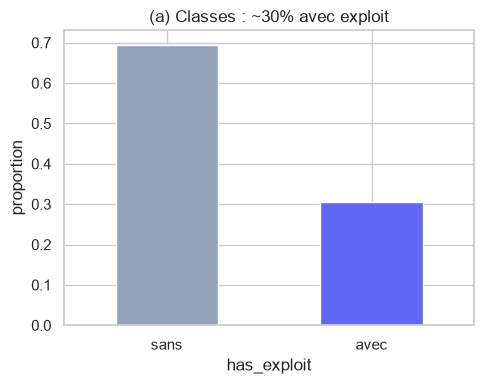

In [7]:
# Part des CVE avec / sans exploit connu
plt.figure(figsize=(5, 4))
donnees["has_exploit"].value_counts(normalize=True).sort_index().plot.bar(color=["#94a3b8", "#6366f1"])
plt.title("(a) Classes : ~%.0f%% avec exploit" % (100 * donnees['has_exploit'].mean()))
plt.xticks([0, 1], ["sans", "avec"], rotation=0)
plt.ylabel("proportion")
plt.tight_layout(); plt.show()


**(b) Le taux d'exploit par année** - les CVE récentes en ont mécaniquement moins (censure à droite).

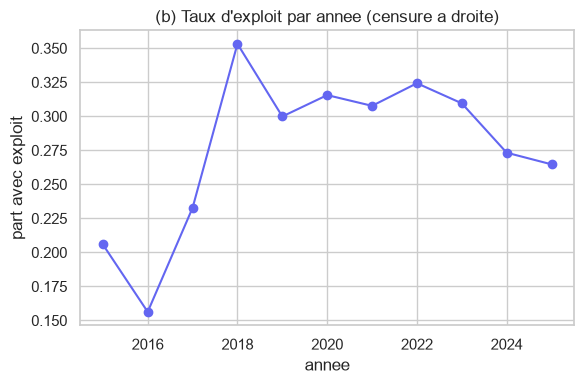

In [8]:
# Taux moyen d'exploit connu, annee par annee
plt.figure(figsize=(6, 4))
donnees[donnees["year"].between(2015, 2025)].groupby("year")["has_exploit"].mean().plot(
    marker="o", color="#6366f1")
plt.title("(b) Taux d'exploit par annee (censure a droite)")
plt.xlabel("annee")
plt.ylabel("part avec exploit")
plt.tight_layout(); plt.show()


**(c) Le lift des mots-clés** - un mot présent rend-il l'exploit plus probable que la moyenne ?

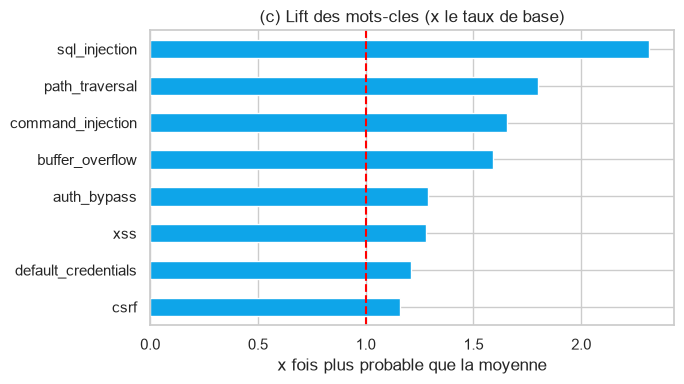

In [9]:
# Lift d'un mot-cle = taux d'exploit quand il est present / taux de base (x fois plus probable)
taux_base = donnees["has_exploit"].mean()
colonnes_kw = [col for col in donnees.columns if col.startswith("kw_")]
lift_par_mot = {col[3:]: donnees.loc[donnees[col] == 1, "has_exploit"].mean() / taux_base
                for col in colonnes_kw if donnees[col].sum() > 300}

# Les 8 mots-cles au plus fort lift
plt.figure(figsize=(7, 4))
pd.Series(lift_par_mot).sort_values().tail(8).plot.barh(color="#0ea5e9")
plt.axvline(1, color="red", ls="--")
plt.title("(c) Lift des mots-cles (x le taux de base)")
plt.xlabel("x fois plus probable que la moyenne")
plt.tight_layout(); plt.show()


Trois constats qui orientent tout :

- **(a)** classes **déséquilibrées** -> je ne jugerai pas sur l'accuracy (prédire "jamais" serait
  trompeur), mais sur PR-AUC / precision@k, et je gérerai le déséquilibre (`class_weight`).
- **(b)** **censure à droite** : les CVE récentes ont mécaniquement moins d'exploits *connus* -> je dois
  **séparer par le temps**, pas au hasard (sinon je "verrais le futur").
- **(c)** des **mots-clés** ont un vrai *lift* -> **le texte de la description est mon signal le plus
  riche**. C'est le coeur du modèle.


## 3bis. Séparation train / test

Avant de préprocesser et de modéliser, on **met de côté un jeu de test** - sinon on se noterait sur des
données déjà vues et on se mentirait sur la performance.

**Par le temps, pas au hasard.** Comme on veut prédire l'**avenir**, on apprend sur le **passé** (CVE
<= 2024) et on teste sur l'**année suivante** (2025), jamais vue. Un découpage aléatoire laisserait le modèle
"voir le futur" (une CVE de 2025 glissée dans le train) -> score trop beau et trompeur. C'est aussi la base
de l'**anti-fuite** : tout le préprocessing sera ajusté (`fit`) sur le **train seul** (§4).

**Et un jeu de *validation* ?** Pas de 3ᵉ jeu figé : la validation se fait en **validation croisée *dans* le
train** - `TimeSeriesSplit` pour régler les hyperparamètres `C` et `penalty` (§6bis) et `cv=3` pour la calibration (§7). Avantages : meilleure utilisation des données, estimation plus robuste, et le **test 2025 reste intouché** (utilisé une seule fois, à la fin) -> aucune fuite du test.


In [10]:
# Split TEMPOREL (et non aleatoire) : on apprend sur le passe, on teste sur l'annee suivante.
# On predit l'avenir + anti-fuite (les CVE recentes ont moins d'exploits connus -- censure).
train = donnees[donnees["year"] <= 2024]
test = donnees[donnees["year"] == 2025]

print("Train (<= 2024) :", len(train))
print("Test  (2025)    :", len(test))
print("Taux d'exploit  -- train : %.1f%%  |  test : %.1f%%"
      % (100 * train["has_exploit"].mean(), 100 * test["has_exploit"].mean()))


Train (<= 2024) : 291677
Test  (2025)    : 45275
Taux d'exploit  -- train : 31.6%  |  test : 26.5%


## 4. Le préprocessing

Trois natures de colonnes, trois traitements - assemblés dans un `ColumnTransformer` (ce qui garantit un
ajustement **sur le train seul**, anti-fuite) :

- **catégorielles** -> *one-hot* (valeurs rares regroupées) ;
- **numériques** -> `log1p` (compteurs asymétriques) puis mise à l'échelle ;
- **texte** -> **présence de mots** (unigrammes binaires). J'ai choisi la *présence* plutôt que TF-IDF :
  ici la fréquence n'aide pas, et la présence reste **interprétable**.

**Valeurs manquantes.** Pas de `SimpleImputer` ici : le **manquant est un signal** (une CVE mal documentée
est souvent atypique), traité **en amont** dès l'extraction. Côté **catégoriel**, l'absence devient la
catégorie **"missing"** (et une valeur inconnue au scoring est neutralisée par `handle_unknown="ignore"`) ;
côté **numérique**, `extract_features` pose une valeur par défaut. On **n'invente pas** de moyenne - ce qui
effacerait justement l'information d'absence.


In [11]:

# Les colonnes qui nourrissent le modele, regroupees par type (copiees ici pour l'autonomie du notebook).
# Categorielles (13) : profil CVSS + type de faille (CWE) + editeur
# NB : nvd_status RETIRE (proxy de maturite de fiche / temporel -> fuite a T0, cf. 10). Correctif partiel.
CAT_FEATURES = [
    "attack_vector", "attack_complexity", "attack_requirements", "privileges_required",
    "user_interaction", "scope", "impact_conf", "impact_integ", "impact_avail",
    "cvss_version", "cpe_part", "primary_cwe", "vendor",
]

# Numeriques (27) : longueurs/compteurs + flags "type de vuln" issus de mots-cles curated (kw_*)
NUM_FEATURES = [
    "desc_len", "cwe_count", "n_vuln_types", "has_patch", "has_vendor_advisory", "n_mitre",
    "cpe_multi_condition", "rce_profile",
    "kw_sql_injection", "kw_xss", "kw_command_injection", "kw_path_traversal", "kw_buffer_overflow",
    "kw_out_of_bounds", "kw_use_after_free", "kw_integer_overflow", "kw_race_condition",
    "kw_deserialization", "kw_csrf", "kw_xxe", "kw_privilege_escalation", "kw_dos",
    "kw_auth_bypass", "kw_rce", "kw_unauthenticated", "kw_default_credentials", "kw_no_user_interaction",
]

# Texte (1) : la description libre de la CVE
TEXT_FEATURE = "description"

# Le pipeline complet (pretraitement + modele), detaille ligne a ligne : c'est le coeur de la logique ML


def build_pipeline():
    # ColumnTransformer : applique un traitement propre a chaque groupe de colonnes, puis concatene tout
    pretraitement = ColumnTransformer([

        # Branche categorielles : OneHot = une colonne 0/1 par modalite.
        # min_frequency=50 : les modalites rares (editeurs marginaux...) sont regroupees dans un bucket "rare".
        # handle_unknown="ignore" : en prod, une valeur jamais vue ne plante pas (ses colonnes restent a 0).
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), CAT_FEATURES),

        # Branche numeriques : un petit pipeline en deux temps.
        # FunctionTransformer(np.log1p, feature_names_out="one-to-one") : applique log1p = log(1+x)
        #   (compresse les compteurs tres etales, le +1 accepte 0) en gardant les noms de colonnes.
        # StandardScaler(with_mean=False) : met a l'echelle sans recentrer (preserve une matrice creuse).
        ("num", Pipeline([("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                          ("sc", StandardScaler(with_mean=False))]), NUM_FEATURES),

        # Branche texte : unigrammes BINAIRES (presence d'un mot, pas sa frequence ; donc pas de TF-IDF).
        # min_df=100 : ne garde que les mots vus dans au moins 100 CVE (ecarte le bruit trop rare).
        ("txt", CountVectorizer(binary=True, min_df=100), TEXT_FEATURE),
    ])

    # Le classifieur : regression logistique. max_iter=1000 pour laisser converger la descente de gradient ;
    # class_weight="balanced" compense le desequilibre (~30% de positifs) en ponderant plus la classe rare.
    # penalite (L2 par defaut) et C sont regles au 6bis (grille 2D) ; C=0.1 fixe en 6bis/7 via set_params.
    classifieur = LogisticRegression(max_iter=1000, class_weight="balanced")

    # Pipeline : enchaine "pretraitement puis modele". Un seul .fit() ajuste les deux, sur le TRAIN seul.
    return Pipeline([("pre", pretraitement), ("clf", classifieur)])

# On ajuste le pretraitement sur le TRAIN COMPLET (<=2024) = exactement le modele livre
# -> le nombre de colonnes affiche est le VRAI (pas celui d'un echantillon reduit).
train_schema = donnees[donnees["year"] <= 2024]
pretraitement_ajuste = build_pipeline().named_steps["pre"]
pretraitement_ajuste.fit(train_schema, train_schema["has_exploit"])

# Libelle, traitement et couleur de chaque branche (pour le schema)
branches = {"cat": ("Categorielles", "OneHot (regroupe les rares)", "#6366f1"),
            "num": ("Numeriques", "log1p + mise a l'echelle", "#0ea5e9"),
            "txt": ("Texte (description)", "presence binaire (unigrammes)", "#f59e0b")}

# Nombre de colonnes en entree et en sortie de chaque branche
col_entree = {nom: (1 if isinstance(cols, str) else len(cols))
              for nom, transfo, cols in pretraitement_ajuste.transformers_ if nom in branches}
col_sortie = {nom: (sl.stop - sl.start)
              for nom, sl in pretraitement_ajuste.output_indices_.items() if nom in branches}
total_colonnes = sum(col_sortie.values())
print("Colonnes produites (train complet) : cat %d + num %d + texte %d = %d"
      % (col_sortie["cat"], col_sortie["num"], col_sortie["txt"], total_colonnes))


Colonnes produites (train complet) : cat 680 + num 27 + texte 4792 = 5499


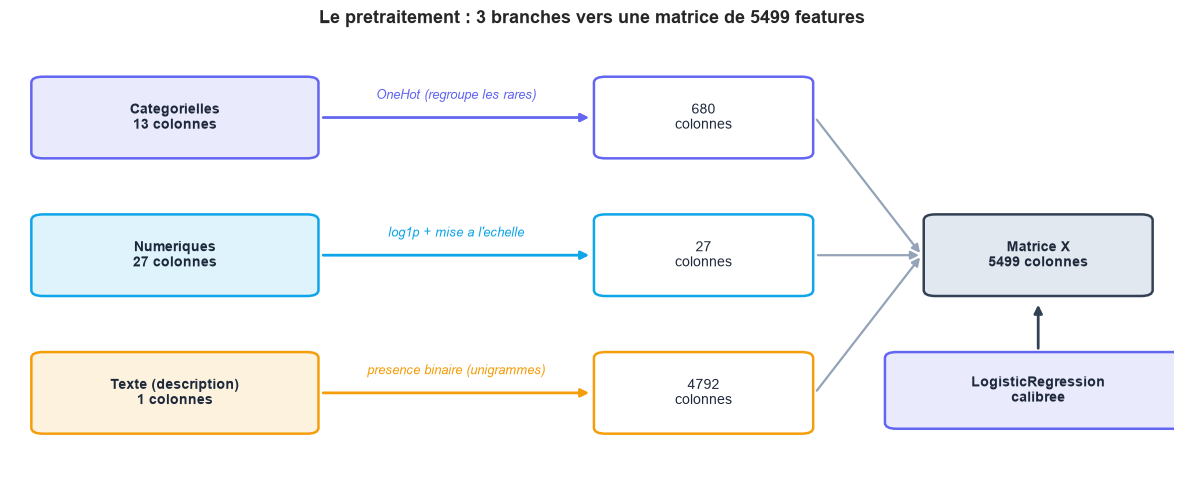

In [12]:
# Schema du pretraitement : 3 branches par type de colonne, concatenees en une matrice
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 12); ax.set_ylim(0, 9); ax.axis("off")


# Petite fonction pour dessiner une boite arrondie avec du texte
def boite(x, y, largeur, hauteur, texte, couleur, remplissage="white", gras=False):
    ax.add_patch(FancyBboxPatch((x, y), largeur, hauteur, boxstyle="round,pad=0.08,rounding_size=0.12",
                                linewidth=1.8, edgecolor=couleur, facecolor=remplissage))
    ax.text(x + largeur / 2, y + hauteur / 2, texte, ha="center", va="center", fontsize=10,
            color="#1e293b", fontweight="bold" if gras else "normal")


# Une ligne par branche : entree, traitement, nb de colonnes produites, puis la matrice
y_positions = {"cat": 6.5, "num": 3.7, "txt": 0.9}
for cle in ("cat", "num", "txt"):
    libelle, traitement, couleur = branches[cle]
    y = y_positions[cle]
    boite(0.3, y, 2.8, 1.5, "%s\n%d colonnes" % (libelle, col_entree[cle]), couleur,
          remplissage=couleur + "22", gras=True)
    ax.annotate("", xy=(6.0, y + 0.75), xytext=(3.2, y + 0.75),
                arrowprops=dict(arrowstyle="-|>", color=couleur, lw=2))
    ax.text(4.6, y + 1.2, traitement, ha="center", va="center", fontsize=9, color=couleur, style="italic")
    boite(6.1, y, 2.1, 1.5, "%d\ncolonnes" % col_sortie[cle], couleur)
    ax.annotate("", xy=(9.4, 4.45), xytext=(8.3, y + 0.75),
                arrowprops=dict(arrowstyle="-|>", color="#94a3b8", lw=1.6))

# La matrice concatenee, puis le modele
boite(9.5, 3.7, 2.2, 1.5, "Matrice X\n%d colonnes" % total_colonnes, "#334155",
      remplissage="#e2e8f0", gras=True)
ax.annotate("", xy=(10.6, 3.5), xytext=(10.6, 2.5),
            arrowprops=dict(arrowstyle="-|>", color="#334155", lw=2))
boite(9.1, 1.0, 3.0, 1.4, "LogisticRegression\ncalibree", "#6366f1", remplissage="#6366f122", gras=True)

ax.set_title("Le pretraitement : 3 branches vers une matrice de %d features" % total_colonnes,
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


### De ~40 features à ~5 500 colonnes : d'où vient ce nombre ?

Le Parquet a **59 colonnes**, mais toutes ne nourrissent pas le modèle : **41 sont des features** (13
catégorielles + 27 numériques + 1 texte) ; les autres sont le **label** et ses variantes, l'`id`, les
**dates**, les compteurs de popularité **exclus** (§9), `nvd_status` **exclu** (proxy temporel, §10) et
l'**EPSS** gardé à part pour le benchmark (§8bis) - jamais une feature.

Le préprocessing **éclate** ensuite ces colonnes (*le compte exact est affiché sous le schéma ci-dessus*,
calculé sur le train complet) :
- chaque **catégorielle** devient une colonne 0/1 *par modalité* (one-hot) : les 13 colonnes deviennent
  quelques **centaines** (ex. `vendor` a des centaines de valeurs, les rares regroupées via `min_frequency`) ;
- la **description** devient une colonne 0/1 *par mot* du vocabulaire retenu (`min_df=100`) : 1 colonne
  devient **plusieurs milliers** de mots ;
- les **27 numériques** restent 27.

Total ~ **5 500 colonnes** (train complet). La matrice est **très éparse** (presque que des 0 : une CVE ne
contient qu'une poignée de ces mots) - normal pour du texte, et c'est justement le terrain où un modèle
**linéaire** est efficace et lisible (un poids par mot).


### `fit`, `transform`, `fit_transform` - et pourquoi c'est crucial

Un transformateur scikit-learn fonctionne en **deux temps** :

- **`fit`** - il *apprend* ses paramètres sur les données : le `OneHotEncoder` mémorise la liste des
  catégories, le scaler calcule moyenne/écart-type, le `CountVectorizer` construit son vocabulaire.
- **`transform`** - il *applique* ces paramètres pour produire la matrice.
- **`fit_transform`** - les deux d'un coup (`fit` puis `transform`), plus rapide - mais **à réserver au
  train**.

**Pourquoi c'est crucial ?** Règle d'or anti-fuite : on **`fit` sur le train uniquement**, puis on
**`transform` le train ET le test** avec les paramètres appris. Si j'ajustais le scaler ou le vocabulaire
en *voyant* le test, je laisserais fuiter de l'information du futur dans l'entraînement -> score optimiste
et **faux**. Concrètement : `fit_transform(train)` d'un côté, `transform(test)` de l'autre - **jamais**
`fit` sur le test.

C'est justement ce que garantit un **`Pipeline`** : `.fit()` sur le pipeline complet `fit` chaque étape
sur le train, et en validation croisée il re-`fit` à chaque pli. *(Ci-dessus, le `pre.fit(train_schema, ...)` ne
servait qu'à **compter les colonnes** pour le schéma.)*


## 4bis. L'effet de la mise à l'échelle (sans vs avec)

Pourquoi mettre les nombres à la même échelle ? Démonstration : le **même** modèle linéaire, sur les mêmes
features structurées, **sans** puis **avec** `StandardScaler`. (On encode les catégorielles en entiers pour
isoler l'effet du scaling.)


In [13]:

# Encodage simple des categorielles en entiers + log1p des numeriques (fit sur le train seul)
enc_demo = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1).fit(train[CAT_FEATURES].astype(str))


def _matrice(d):
    return np.c_[enc_demo.transform(d[CAT_FEATURES].astype(str)), np.log1p(d[NUM_FEATURES].to_numpy(float))]


X_tr_demo, X_te_demo = _matrice(train), _matrice(test)

# Meme LogReg (C=0.1, la valeur retenue), sans puis avec mise a l'echelle ; warning de non-convergence capte
for libelle, avec_echelle in [("SANS mise a l'echelle", False), ("AVEC mise a l'echelle", True)]:
    entree_tr, entree_te = X_tr_demo, X_te_demo
    if avec_echelle:
        scaler_demo = StandardScaler().fit(X_tr_demo)
        entree_tr, entree_te = scaler_demo.transform(X_tr_demo), scaler_demo.transform(X_te_demo)
    with warnings.catch_warnings(record=True) as captures:
        warnings.simplefilter("always")
        clf_demo = LogisticRegression(max_iter=1000, class_weight="balanced", C=0.1).fit(entree_tr, train["has_exploit"])
    a_converge = not any(issubclass(c.category, ConvergenceWarning) for c in captures)
    proba_demo = clf_demo.predict_proba(entree_te)[:, 1]
    print("%-22s ROC=%.3f  PR-AUC=%.3f  |  %s en %d iterations" % (
        libelle, roc_auc_score(test["has_exploit"], proba_demo),
        average_precision_score(test["has_exploit"], proba_demo),
        "converge" if a_converge else "NON CONVERGE (plafond)", clf_demo.n_iter_[0]))


SANS mise a l'echelle  ROC=0.761  PR-AUC=0.629  |  NON CONVERGE (plafond) en 1000 iterations


AVEC mise a l'echelle  ROC=0.769  PR-AUC=0.627  |  converge en 24 iterations


Deux effets, tous deux au bénéfice du scaling :

- **Convergence.** Sans mise à l'échelle, le solveur **n'atteint pas** l'optimum dans le budget d'itérations
  (il plafonne à 1000) ; avec, il **converge en ~25 itérations** - ~40x plus rapide et fiable.
- **Performance & régularisation.** Sans scaling, les codes catégoriels (0...des centaines) **écrasent** les
  drapeaux binaires (0/1), et la pénalité `C` s'applique **injustement** (les grandes échelles sont
  relativement moins pénalisées) -> ROC plus bas. Une fois tout mis à échelle comparable, le **ROC remonte**
  (le PR-AUC, lui, reste stable - le signal fort ici est le texte, pas ces quelques colonnes numériques).

C'est pourquoi le pipeline **met les numériques à l'échelle** (un modèle à arbres, lui, s'en moquerait).


## 5. Comment un modèle "apprend" ? La descente de gradient, à la main

Avant scikit-learn, je veux **démystifier `.fit()`**. Une régression logistique apprend des poids `w` :
elle calcule `z = w-x`, le passe dans une **sigmoïde** -> probabilité, puis ajuste `w` pour réduire
l'erreur (*log-loss*), pas par pas : la **descente de gradient**. Je la code en numpy et je vérifie que je
retrouve scikit-learn.

> **Régression logistique ≠ régression linéaire.** La régression *linéaire* prédit une valeur continue
> (`y = w-x`). La *logistique* réutilise ce même coeur linéaire `z = w-x`, puis le passe dans une sigmoïde
> pour sortir une **probabilité [0-1]** et **classer** (exploit / pas d'exploit) ; elle optimise la
> log-loss, pas l'erreur quadratique.


### Préparer les données pour la démo

Deux gestes de préparation méritent qu'on s'y arrête :

**1. `np.log1p(...)` - écraser les échelles.** Certains compteurs sont très *étalés* : `desc_len` va de
quelques unités à plusieurs milliers. Une poignée de valeurs géantes écraserait alors tout le reste.
`log1p(x) = log(1 + x)` compresse ces grands nombres (1000 -> ~6,9) tout en gardant l'ordre. Le "+1"
sert à accepter la valeur 0 (`log(0)` est indéfini ; `log1p(0) = 0`). Ensuite `StandardScaler` recentre
chaque colonne sur moyenne 0 / écart-type 1 - indispensable pour que la descente de gradient converge
bien. *(`.to_numpy(dtype=float)` ne fait que passer des colonnes pandas à un tableau numpy de flottants,
support des calculs matriciels.)*

**2. La colonne de 1 (le "biais").** Le modèle calcule `z = w-x` (une somme pondérée). Sans terme
constant, quand toutes les features valent 0 on aurait `z = 0` -> probabilité figée à 0,5 : le modèle
serait *forcé de passer par l'origine*. En ajoutant une colonne remplie de `1`, le poids qui lui est
associé (`w[0]`) devient un **niveau de base ajustable** - exactement le `b` de `y = a-x + b`. C'est
l'**ordonnée à l'origine** (*intercept*), que scikit-learn ajoute automatiquement mais qu'ici je pose à la
main pour que rien ne soit magique.


In [14]:

# Quelques features numeriques simples, sur un echantillon, pour la demonstration
features_demo = ["desc_len", "cwe_count", "rce_profile", "kw_rce", "kw_sql_injection", "has_vendor_advisory"]
echantillon = donnees.sample(30000, random_state=RANDOM_STATE)

# to_numpy(float) : colonnes pandas en tableau numpy de flottants (pour les calculs matriciels)
x_numerique = echantillon[features_demo].to_numpy(dtype=float)

# log1p = log(1+x) : compresse les compteurs tres etales (le +1 accepte la valeur 0)
x_numerique = np.log1p(x_numerique)

# StandardScaler : chaque colonne a moyenne 0 / ecart-type 1 pour que la descente de gradient converge bien
X = StandardScaler().fit_transform(x_numerique)

# On ajoute une colonne de 1 = le biais (le "b" de y = a*x + b) : un niveau de base ajustable via w[0]
X = np.c_[np.ones(len(X)), X]

# La cible 0/1
y = echantillon["has_exploit"].to_numpy(dtype=float)


### Les ingrédients de la descente : sigmoïde et taux d'apprentissage

**La sigmoïde** transforme le score brut `z = w-x` (un réel, de −∞ à +∞) en une **probabilité** entre 0
et 1. Sa courbe en S : très négatif -> ~0, très positif -> ~1, et **`z = 0` -> exactement 0,5** (le point de
bascule). C'est ce qui permet de lire la sortie comme "X % de chances". Sa formule `1 / (1 + e^(−z))`
est aussi commode : sa dérivée est simple, ce qui rend le calcul du gradient ci-dessous élégant.

**Le taux d'apprentissage `lr`** règle la **taille du pas** à chaque itération. Trop grand -> on saute
par-dessus le minimum, le coût oscille ou diverge ; trop petit -> on avance à peine, il faut des milliers
de pas. Je prends **0,5** parce que mes features sont **standardisées** (moyenne 0 / écart-type 1) : les
gradients sont bien conditionnés, et 0,5 fait converger proprement en ~300 pas - *on le voit* sur la
courbe de coût. En pratique `lr` est un hyperparamètre qu'on règle ; ici c'est une valeur de démonstration
choisie parce qu'elle marche bien sur ces données mises à l'échelle.


In [15]:
# Sigmoide : score reel z=w.x en probabilite [0,1]. Courbe en S : z=0 donne 0.5, z tres grand donne 1, z tres petit donne 0.
# Formule 1/(1+e^-z) ; sa derivee vaut sigmoid(z)*(1-sigmoid(z)), d'ou un gradient tres simple plus bas.
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# Poids initiaux : tous nuls (le modele part "neutre" et apprend pas a pas)
w = np.zeros(X.shape[1])

# Taux d'apprentissage = taille du pas. 0.5 convient car les features sont standardisees (cf. encadre)
lr = 0.5


### La boucle d'apprentissage : prédire, mesurer, corriger

À chaque tour de boucle, le modèle répète trois gestes simples.

**1. Prédire.** Avec ses poids actuels, il attribue une probabilité à chaque CVE :

`p = sigmoid(X @ w)`

Le produit `X @ w` calcule le score de *toutes* les CVE en une seule opération (chaque ligne de `X` est une
CVE) ; la sigmoïde transforme ensuite chaque score en probabilité.

**2. Mesurer l'erreur.** On compare ces probabilités `p` à la vérité `y` (0 ou 1) avec la **log-loss** :

`coût = − moyenne( y - log(p) + (1 − y) - log(1 − p) )`

L'idée est simple : si la CVE a vraiment un exploit (`y = 1`), on veut `p` proche de 1 - sinon le coût
grimpe fort ; c'est symétrique pour `y = 0`. Le coût est donc **petit quand les prédictions sont bonnes,
grand sinon**. *(Le `+1e-9` sert juste à éviter `log(0)`.)*

**3. Corriger.** On déplace les poids dans la direction qui fait baisser le coût :

`w = w − lr x gradient`, avec `gradient = X.T @ (p − y) / n`

Ici `(p − y)` est simplement l'écart entre prédiction et vérité pour chaque CVE. Le **gradient** indique,
pour chaque poids, dans quel sens le pousser ; le **taux d'apprentissage `lr`** règle l'ampleur du pas.

Répété 300 fois, le coût descend régulièrement - c'est la courbe ci-dessous.


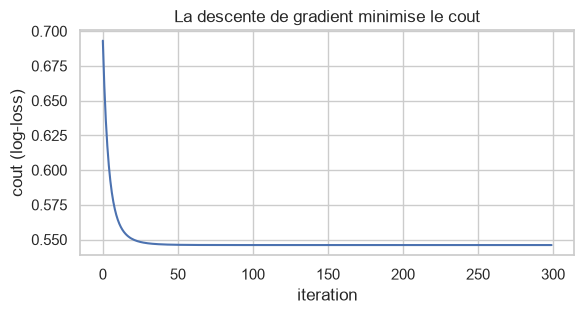

ROC a la main : 0.7206  |  ROC sklearn : 0.7206  identiques (.fit() = cette descente)


In [16]:
# Historique du cout a chaque iteration, pour tracer la convergence
couts = []

# 300 pas de descente de gradient : predire, mesurer, corriger
for _ in range(300):

    # Predire : X @ w = score z de chaque CVE d'un coup (produit matriciel) ; sigmoid donne la proba p par CVE
    p = sigmoid(X @ w)

    # Mesurer : log-loss moyenne. y*log(p) punit un p faible si y=1 ; (1-y)*log(1-p) punit un p fort si y=0
    # Le "-" rend le cout positif ; +1e-9 evite log(0) = -inf
    couts.append(-np.mean(y*np.log(p+1e-9) + (1-y)*np.log(1-p+1e-9)))

    # Corriger : (p - y) = erreur par CVE ; X.T @ (p-y)/n = pente (gradient) ; on descend la pente
    w -= lr * (X.T @ (p - y) / len(y))

plt.figure(figsize=(6, 3.3)); plt.plot(couts)
plt.xlabel("iteration"); plt.ylabel("cout (log-loss)")
plt.title("La descente de gradient minimise le cout"); plt.tight_layout(); plt.show()

# Verification : sklearn doit retrouver le meme ROC que ma descente "a la main". Parametres :
#   C=1e6         : C = inverse de la force de regularisation. Tres grand => quasi AUCUNE regularisation,
#                   pour coller a ma version brute (qui n'en a pas) et comparer a egalite.
#   max_iter=5000 : plafond d'iterations du solveur ; un probleme non regularise converge plus lentement,
#                   donc on laisse de la marge pour qu'il aille au bout.
#   X[:, 1:]      : on ENLEVE la colonne de 1 (le biais ajoute a la main) car LogisticRegression ajoute
#                   deja son propre intercept (fit_intercept=True par defaut) -> sinon on le compte 2 fois.
#   y             : la cible 0/1.
modele_sklearn = LogisticRegression(C=1e6, max_iter=5000).fit(X[:, 1:], y)
print("ROC a la main : %.4f  |  ROC sklearn : %.4f  identiques (.fit() = cette descente)"
      % (roc_auc_score(y, sigmoid(X @ w)), roc_auc_score(y, modele_sklearn.predict_proba(X[:, 1:])[:, 1])))


## 6. Choisir le modèle le plus performant

Je compare **une famille représentative par grande catégorie** de modèles supervisés tabulaires, sur les
seules features **structurées** (sans texte, pour isoler l'effet du modèle) :

- **linéaire** - `LogisticRegression` (rapide, explicable, sert de base) ;
- **bagging d'arbres** - `RandomForest` (robuste, capte les interactions) ;
- **boosting d'arbres** - `HistGradientBoosting` (souvent l'état de l'art sur données tabulaires) ;
- **probabiliste / génératif** - `GaussianNB` (bayésien naïf : hypothèse d'indépendance des features),
  la baseline classique.

Ces trois familles couvrent l'essentiel du spectre utile. J'écarte volontairement :

- le **deep learning** - données structurées de taille modeste, pas de GPU, peu explicable ; et l'étude de
  référence *Expected Exploitability* montre qu'il n'apporte rien sur cette tâche ;
- les **SVM** (*Support Vector Machines*, frontière à marge maximale) - le **linéaire** passe à l'échelle
  et égale la LogReg en classement, mais ne sort **pas de probabilité native** (il faudrait le calibrer
  par-dessus -> aucun gain vs LogReg) ; le **noyau RBF**, lui, ne passe **pas** à l'échelle (O(n²)) sur
  ~365 k lignes ;
- le **KNN** (*k plus proches voisins*) - inadapté au texte épars en haute dimension.

La baseline linéaire a déjà été décortiquée "à la main" au §5.

> **Référence** - *Expected Exploitability: Predicting the Development of Functional Vulnerability
> Exploits*, O. Suciu, C. Nelson, Z. Lyu, T. Bao, T. Dumitraş, **USENIX Security Symposium, 2022**
> ([page USENIX](https://www.usenix.org/conference/usenixsecurity22/presentation/suciu) - preprint
> [arXiv:2102.07869](https://arxiv.org/abs/2102.07869)). C'est le travail le plus proche du nôtre ;
> j'en reprends plusieurs leçons (unigrammes binaires plutôt qu'embeddings, features à T0 faibles, le
> temporel comme vraie source de valeur).

Vu le fort déséquilibre (~30 % de positifs), l'accuracy serait trompeuse ; je juge sur deux mesures de
**qualité du classement** :

- **ROC-AUC** - probabilité qu'une CVE réellement exploitée soit mieux notée qu'une non-exploitée tirée au
  hasard. 0,5 = hasard, 1 = parfait ; robuste mais un peu optimiste quand les positifs sont rares.
- **PR-AUC** - aire sous la courbe précision/rappel, plus exigeante et plus parlante sur données
  déséquilibrées ; sa référence "au hasard" est la proportion de positifs (~0,3 ici), pas 0,5.


Donnees d'entrainement : 30000
Donnees de test        : 10000


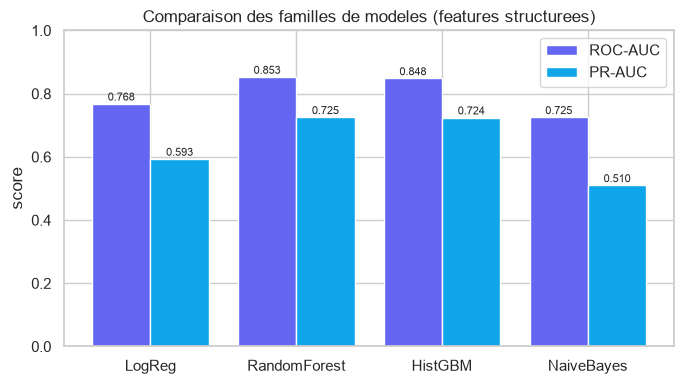

In [17]:

# Echantillon pour aller vite
echantillon = donnees.sample(40000, random_state=RANDOM_STATE)

# OrdinalEncoder : chaque modalite -> un entier. handle_unknown="use_encoded_value" + unknown_value=-1 :
# une categorie jamais vue au test recoit -1 au lieu de faire planter le transform.
encodeur = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_struct = np.c_[encodeur.fit_transform(echantillon[CAT_FEATURES].astype(str)),
                 echantillon[NUM_FEATURES].to_numpy(dtype=float)]

# Mise a l'echelle : indispensable au lineaire, neutre pour les arbres
X_struct = StandardScaler().fit_transform(X_struct)
y_struct = echantillon["has_exploit"].to_numpy()

# train_test_split coupe les donnees en deux, avec un role precis pour chaque variable :
#   X_train, y_train  : features + label vus pendant l'entrainement
#   X_test,  y_test   : features + label gardes de cote pour l'evaluation (jamais vus a l'entrainement)
#   test_size=.25     : 25% des lignes vont au test, 75% au train
#   random_state      : graine fixe -> meme decoupage a chaque execution (reproductible)
#   stratify=y_struct : echantillonnage STRATIFIE -> garde la MEME proportion d'exploits (~30%) dans le
#                       train ET le test. Sans lui, un tirage aleatoire pourrait sur- ou sous-representer la
#                       classe rare dans le test -> evaluation biaisee et instable. On stratifie sur y (le
#                       label) : crucial quand les classes sont desequilibrees.
# NB : split ALEATOIRE ici, juste pour comparer des familles de modeles ; le split TEMPOREL vient ensuite.
X_train, X_test, y_train, y_test = train_test_split(
    X_struct, y_struct, test_size=.25, random_state=RANDOM_STATE, stratify=y_struct)

# Tailles des jeux apres decoupage
print("Donnees d'entrainement :", len(X_train))
print("Donnees de test        :", len(X_test))

# On entraine et on evalue trois familles : lineaire, foret, gradient boosting
modeles = {
    # LogReg : max_iter=3000 (iterations max de convergence) ; class_weight="balanced" (pondere la classe rare)
    "LogReg": LogisticRegression(max_iter=3000, class_weight="balanced"),
    # RandomForest : n_estimators=200 (nb d'arbres) ; n_jobs=-1 (tous les coeurs CPU) ; class_weight equilibre
    "RandomForest": RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                           n_jobs=-1, random_state=RANDOM_STATE),
    # HistGBM : gradient boosting sur histogrammes (gere NaN et categorielles nativement) ; defauts sklearn
    "HistGBM": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    # NaiveBayes : famille PROBABILISTE / generative (hypothese d'independance des features) ; baseline
    "NaiveBayes": GaussianNB(),
}
resultats = {}
for nom, modele in modeles.items():
    proba = modele.fit(X_train, y_train).predict_proba(X_test)[:, 1]
    resultats[nom] = (roc_auc_score(y_test, proba), average_precision_score(y_test, proba))

# Graphe : ROC-AUC et PR-AUC de chaque famille (barres groupees, valeurs annotees)
noms = list(resultats)
roc = [resultats[nom][0] for nom in noms]
pr = [resultats[nom][1] for nom in noms]
positions = np.arange(len(noms))
plt.figure(figsize=(7, 4))
plt.bar(positions - 0.2, roc, 0.4, label="ROC-AUC", color="#6366f1")
plt.bar(positions + 0.2, pr, 0.4, label="PR-AUC", color="#0ea5e9")
for i in range(len(noms)):
    plt.text(positions[i] - 0.2, roc[i] + 0.01, "%.3f" % roc[i], ha="center", fontsize=8)
    plt.text(positions[i] + 0.2, pr[i] + 0.01, "%.3f" % pr[i], ha="center", fontsize=8)
plt.xticks(positions, noms)
plt.ylim(0, 1)
plt.ylabel("score")
plt.legend()
plt.title("Comparaison des familles de modeles (features structurees)")
plt.tight_layout(); plt.show()


**Alors pourquoi ne pas garder RandomForest, qui gagne sur ce graphe ?** Parce qu'il ne gagne que
sur les features **structurées**. Or mon signal le plus fort n'est pas là : c'est le **texte** (§3c), qui
donne une matrice **éparse** de plusieurs milliers de colonnes (cf. §4). Sur ce type de données, le classement s'inverse :

- la **régression logistique** exploite très bien le texte épars et **dépasse les arbres** une fois le
  texte ajouté (je le vérifie juste après : ~0,91 contre ~0,86 pour les arbres sur le structuré seul) ;
- les **arbres** (RandomForest, HistGBM) gèrent mal des milliers de colonnes éparses - coûteux, et ils
  perdent l'**interprétabilité** (pas de "poids par mot").

Le bon modèle n'est donc pas "le meilleur sur le structuré", mais **celui qui tire parti du texte**. Je
le montre en ajoutant le texte à la régression logistique :


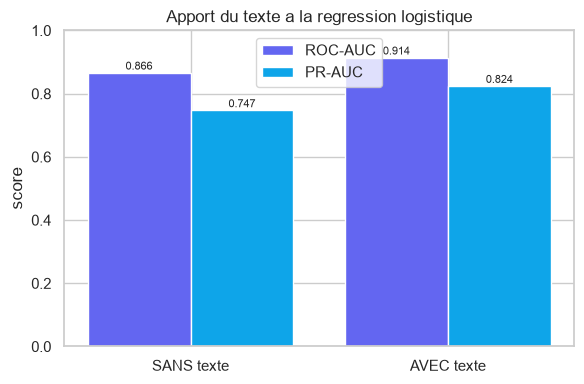

In [18]:

# train / test : le split TEMPOREL defini en section 3bis (train <= 2024, test = 2025), sur tout le corpus.


# Construit le pipeline ; le texte est optionnel pour pouvoir mesurer son apport
def construire_pipeline(avec_texte):

    # Un traitement par type de colonne : categorielles en one-hot, numeriques en log1p + echelle
    etapes = [
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), CAT_FEATURES),
        ("num", Pipeline([("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                          ("sc", StandardScaler(with_mean=False))]), NUM_FEATURES),
    ]

    # Presence de mots (binaire), pas TF-IDF : simple et interpretable ; min_df=100 = mots assez frequents
    if avec_texte:
        etapes.append(("txt", CountVectorizer(binary=True, min_df=100), TEXT_FEATURE))

    return Pipeline([("pre", ColumnTransformer(etapes)),
                     ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))])


# Meme modele, sans puis avec le texte : on stocke ROC et PR-AUC de chaque variante
resultats_texte = {}
for avec_texte in (False, True):
    proba = construire_pipeline(avec_texte).fit(train, train["has_exploit"]).predict_proba(test)[:, 1]
    etiquette = "AVEC texte" if avec_texte else "SANS texte"
    resultats_texte[etiquette] = (roc_auc_score(test["has_exploit"], proba),
                                  average_precision_score(test["has_exploit"], proba))

# Graphe : l'apport du texte (barres groupees, valeurs annotees)
noms = list(resultats_texte)
roc = [resultats_texte[nom][0] for nom in noms]
pr = [resultats_texte[nom][1] for nom in noms]
positions = np.arange(len(noms))
plt.figure(figsize=(6, 4))
plt.bar(positions - 0.2, roc, 0.4, label="ROC-AUC", color="#6366f1")
plt.bar(positions + 0.2, pr, 0.4, label="PR-AUC", color="#0ea5e9")
for i in range(len(noms)):
    plt.text(positions[i] - 0.2, roc[i] + 0.01, "%.3f" % roc[i], ha="center", fontsize=8)
    plt.text(positions[i] + 0.2, pr[i] + 0.01, "%.3f" % pr[i], ha="center", fontsize=8)
plt.xticks(positions, noms)
plt.ylim(0, 1)
plt.ylabel("score")
plt.legend()
plt.title("Apport du texte a la regression logistique")
plt.tight_layout(); plt.show()


## 6bis. Régler les hyperparamètres

La régression logistique **minimise la log-loss** (perte logistique, vue "à la main" en §5) ; on **règle**
sa **régularisation** : sa *force* (`C`) **et** son *type* (`penalty`).

> **La régularisation en un mot.** En plus de "coller aux données" (la log-loss), on ajoute au coût une
> **pénalité sur la taille des poids** : elle empêche le modèle de prendre de trop gros poids pour épouser
> le moindre détail (donc le bruit) -> il **généralise mieux** et sur-apprend moins. `C` est l'**inverse**
> de cette *force* : **petit `C` = forte régularisation** (poids bridés), **grand `C` = quasi aucune**.
> *(C'est pourquoi, au §5, `C = 1e6` désactivait la pénalité pour comparer sklearn à ma descente "à la
> main", qui n'en a pas.)*
>
> **Deux *types* de pénalité.** La **L2** (défaut) pénalise la **somme des carrés** des poids : elle les
> **rétrécit** tous vers zéro sans en annuler aucun. La **L1** ("lasso") pénalise la **somme des valeurs
> absolues** : elle en met une **partie exactement à zéro** -> elle fait de la **sélection de variables**
> (utile ici : ~4 800 unigrammes de texte, dont beaucoup inutiles). C'est mon **second hyperparamètre**.

Je règle **les deux ensemble** (`C` **et** `penalty`) par **recherche sur grille** (`GridSearchCV`) - une
grille **2D** -, avec une **validation croisée temporelle** (`TimeSeriesSplit`) et non un `KFold` aléatoire :
on doit toujours valider sur des CVE **postérieures** à celles d'entraînement (même raison que le split
temporel).

> **Et `max_iter` ?** Ce n'est **pas** un hyperparamètre à régler : c'est le **budget d'itérations** laissé
> au solveur pour converger. Une fois convergé (ici bien avant 1000), l'augmenter ne change **rien** à la
> solution ; le baisser livrerait juste un modèle **pas fini d'entraîner**. On le fixe assez grand, point.


In [19]:

# Sous-echantillon du train : les CVE les plus RECENTES (tail), au plus pres des conditions de deploiement,
# et deja ordonnees dans le temps (indispensable a TimeSeriesSplit)
train_hp = train.sort_values("nvd_published").tail(60000)

# Grille 2D : (type de penalite via l1_ratio) x (force C).
#   l1_ratio=1 -> penalite L1 pure (lasso) ; l1_ratio=0 -> L2 pure. (API sklearn 1.8+, remplace penalty=.)
#   solver="liblinear" : solveur rapide gerant L1 ET L2 en binaire.
grille = {"clf__solver": ["liblinear"],
          "clf__l1_ratio": [1, 0],
          "clf__C": [0.03, 0.1, 0.3]}

# TimeSeriesSplit(3) : 3 plis chronologiques ; scoring=PR-AUC (adapte au desequilibre)
recherche = GridSearchCV(build_pipeline(), grille, cv=TimeSeriesSplit(n_splits=3),
                         scoring="average_precision", n_jobs=-1)
recherche.fit(train_hp, train_hp["has_exploit"])

# On affiche la grille classee du meilleur au moins bon (PR-AUC en CV temporelle)
resultats = sorted(zip(recherche.cv_results_["params"], recherche.cv_results_["mean_test_score"]),
                   key=lambda t: -t[1])
for params, score in resultats:
    penalite = "L1" if params["clf__l1_ratio"] == 1 else "L2"
    marque = "  <- meilleur" if params == recherche.best_params_ else ""
    print("penalite=%s C=%-5s -> PR-AUC (CV temporelle) = %.3f%s"
          % (penalite, params["clf__C"], score, marque))


penalite=L2 C=0.03  -> PR-AUC (CV temporelle) = 0.814  <- meilleur
penalite=L2 C=0.1   -> PR-AUC (CV temporelle) = 0.812
penalite=L1 C=0.3   -> PR-AUC (CV temporelle) = 0.808
penalite=L1 C=0.1   -> PR-AUC (CV temporelle) = 0.808
penalite=L2 C=0.3   -> PR-AUC (CV temporelle) = 0.807
penalite=L1 C=0.03  -> PR-AUC (CV temporelle) = 0.793


**Lecture.** Sur nos données, la grille 2D place la **pénalité L2 (par défaut)** en tête, la **L1** juste
derrière : l'écart (~0,01 de PR-AUC) est **dans le bruit** - d'ailleurs il **s'inverse** si on change de
sous-échantillon ou de jeu de données. Autrement dit, **les deux pénalités se valent ici** ; je **garde la
L2**, la valeur par défaut, comme choix le plus simple et robuste.

**Ce que la L1 aurait apporté (et pourquoi je m'en passe).** La L1 ("lasso") met une partie des
coefficients **exactement à zéro** -> sélection de variables (modèle plus sparse). C'est séduisant pour la
lisibilité, **mais** comme elle **n'améliore pas la performance** ici, je ne complique pas le modèle pour
rien : à performance égale, le plus simple gagne.

*Note sur `C` :* dans la plage `0,03-0,1` le score est sur un **plateau** (gain dans le bruit) ; je retiens
`C = 0,1`, stable. La bonne démarche : **balayer une grille**, repérer le **plateau**, puis choisir en
connaissance de cause - jamais au bord, jamais au hasard.

*Et `max_iter` ?* Ce n'était volontairement **pas** dans la grille : c'est un **budget de convergence**, pas
un levier de performance (une fois le solveur convergé, l'augmenter ne change rien).


## 7. Calibrer les probabilités

Un modèle peut **bien classer** (bon ROC-AUC) tout en sortant des probabilités **fausses en valeur** : par
exemple annoncer 0,9 pour des CVE qui, en réalité, n'ont un exploit qu'une fois sur deux. Le classement
est correct, mais le *chiffre* ne veut rien dire.

**Pourquoi ça compte ici ?** Je livre un **score** (façon EPSS), pas seulement un classement : un analyste
doit pouvoir lire "0,7" comme "~70 % de chances qu'un exploit existe" et fixer un seuil en confiance.
Une probabilité juste est donc un livrable en soi.

**Pourquoi mon modèle en a besoin ?** Deux effets se cumulent : (1) `class_weight="balanced"` sur-pondère
la classe rare pendant l'apprentissage, ce qui **gonfle** les probabilités vers le haut ; (2) une
régression logistique n'est pas parfaitement calibrée par construction. On obtient donc des scores bons
pour *trier*, mais **biaisés en niveau**.

**La solution.** `CalibratedClassifierCV` enveloppe le pipeline et apprend, par validation croisée (`cv=3`,
sur des plis non vus), une fonction qui **recale** les scores bruts en probabilités honnêtes (méthode
*sigmoïde*, dite de Platt). Je vérifie le résultat de deux façons : la **courbe de fiabilité** (proche de
la diagonale = fiable) et le **score de Brier** (l'erreur moyenne des probabilités, plus bas = mieux).


Test 2025 (n=45275) : ROC=0.905  PR-AUC=0.818  Brier=0.1030


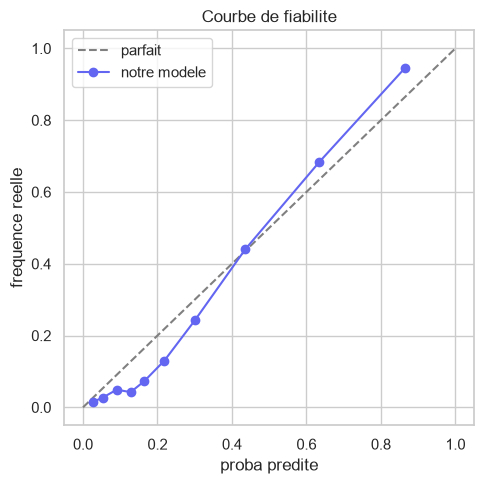

In [20]:

# On part du pipeline regle avec le meilleur reglage du 6bis (set_params cible l'etape "clf")
# Retenu : penalite L2 (defaut, gagnante sur nos donnees) + C=0.1 (plateau)
pipeline_regle = build_pipeline().set_params(clf__C=0.1)

# CalibratedClassifierCV enveloppe le pipeline et recale les probabilites (methode sigmoid = Platt).
# cv=3 : la calibration se fait par validation croisee ( re-entraine le pipeline sur 2 plis, calibre sur le
# 3e, puis moyenne). 3 plis = compromis cout/qualite : assez pour une calibration stable sans multiplier
# par 5 ou 10 le temps d'entrainement (chaque pli re-entraine tout le pipeline, texte compris).
modele_calibre = CalibratedClassifierCV(pipeline_regle, method="sigmoid", cv=3)

# Entraine sur TOUT le train (<= 2024) : performance reelle, pas un echantillon
modele_calibre.fit(train, train["has_exploit"])

# Probabilites sur le test (2025, jamais vu)
proba_test = modele_calibre.predict_proba(test)[:, 1]

# Brier = erreur des probabilites (plus bas = mieux)
print("Test 2025 (n=%d) : ROC=%.3f  PR-AUC=%.3f  Brier=%.4f"
      % (len(test), roc_auc_score(test["has_exploit"], proba_test),
         average_precision_score(test["has_exploit"], proba_test),
         brier_score_loss(test["has_exploit"], proba_test)))

# Courbe de fiabilite : on regroupe les CVE selon leur proba predite, puis on compare la proba moyenne du
# groupe (axe x) a la frequence reelle d'exploits dans ce groupe (axe y). Proche de la diagonale = fiable.
#   n_bins=10           : 10 groupes
#   strategy="quantile" : groupes de MEME effectif (et non de meme largeur) -> plus robuste quand les
#                         probas sont concentrees. Renvoie (frequence reelle, proba moyenne) par groupe.
freq_reelle, proba_moyenne = calibration_curve(test["has_exploit"], proba_test, n_bins=10, strategy="quantile")
plt.figure(figsize=(5, 5)); plt.plot([0, 1], [0, 1], "--", color="grey", label="parfait")
plt.plot(proba_moyenne, freq_reelle, "o-", color="#6366f1", label="notre modele")
plt.xlabel("proba predite"); plt.ylabel("frequence reelle"); plt.legend()
plt.title("Courbe de fiabilite"); plt.tight_layout(); plt.show()


### Le modèle final, vu par scikit-learn

En complément du schéma fait main (§4), voici le **diagramme natif** de scikit-learn du **modèle retenu** :
la calibration (`CalibratedClassifierCV`) enveloppant le `Pipeline` (`ColumnTransformer` + `LogisticRegression`).
Interactif dans Jupyter - chaque bloc se déplie et affiche ses paramètres au survol.


In [21]:
# Diagramme HTML natif scikit-learn de l'ARCHITECTURE du modele final retenu :
# CalibratedClassifierCV enveloppant le Pipeline (ColumnTransformer + LogisticRegression).
set_config(display="diagram")
CalibratedClassifierCV(build_pipeline().set_params(clf__C=0.1),
                       method="sigmoid", cv=3)


,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step..._iter=1000))])
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to 

La courbe suit la diagonale : les probabilités sont **fiables**, exploitables telles quelles.

**Le score de Brier** est l'**erreur quadratique moyenne** entre la probabilité prédite et le résultat réel
(0 ou 1) : `Brier = moyenne( (proba − vérité)² )`. 0 = parfait, plus c'est bas mieux c'est. Contrairement à
la courbe (visuelle), c'est **un seul chiffre** qui résume à la fois la calibration *et* la finesse des
probabilités - donc facile à suivre automatiquement.

**Suivre la dérive (*drift*) en production.** Le monde change (nouvelles familles de vulnérabilités,
nouveaux éditeurs) et le modèle peut se dégrader. Deux niveaux de surveillance :

- *sans attendre les labels* - comparer la **distribution des scores** du jour à celle d'entraînement (via
  un **PSI**, *Population Stability Index*) et surveiller la distribution des features en entrée : un
  décalage signale un *data drift* précoce ;
- *quand les labels arrivent* (une CVE finit par recevoir - ou non - un exploit) - recalculer **Brier** et
  **PR-AUC** sur les CVE récentes et suivre ces courbes dans le temps.

**Y remédier.** Le label se **corrige tout seul** (un "0" d'aujourd'hui devient "1" quand l'exploit
paraît). Je planifie donc un **ré-entraînement périodique** (cron) : reconstruire le dataset, ré-entraîner,
puis **ne promouvoir le nouveau modèle que s'il bat l'ancien** sur une période de validation
(*champion / challenger*) - sinon on garde l'ancien (*rollback*). Le Brier, chiffre unique, sert de
**garde-fou automatique** dans ce pipeline.


## 7bis. Ce que le modèle a appris (interprétabilité + audit anti-fuite)

Gros avantage du linéaire : **chaque feature a un poids**. On peut donc lire *pourquoi* le modèle décide -
et surtout **auditer** qu'aucun mot "traître" (qui révélerait directement l'existence d'un exploit :
`exploit`, `metasploit`, `poc`...) ne s'est glissé dans le vocabulaire. Ce serait une **fuite**.


In [22]:
# On relit les coefficients du modele RETENU (L2, C=0.1), non calibre : memes rangs, coefficients lisibles
pipe_interpret = build_pipeline().set_params(clf__C=0.1).fit(train, train["has_exploit"])
noms_features = pipe_interpret.named_steps["pre"].get_feature_names_out()
coefficients = pipe_interpret.named_steps["clf"].coef_[0]
poids = pd.Series(coefficients, index=noms_features).sort_values()

# Les features qui POUSSENT le score vers "exploit existe", et celles qui le tirent vers le bas
print("== Poussent vers 'exploit existe' ==")
print(poids.tail(12).iloc[::-1].round(2).to_string())
print("\n== Tirent vers 'pas d'exploit' ==")
print(poids.head(8).round(2).to_string())


== Poussent vers 'exploit existe' ==
txt__disclosed              2.34
txt__outputting             1.83
txt__sanitise               1.56
txt__github                 1.28
txt__tensorflow             1.26
cat__vendor_lunary          1.20
cat__vendor_jerryscript     1.17
cat__primary_cwe_CWE-680    1.15
cat__vendor_mikrotik        1.13
cat__vendor_openlinksw      1.13
txt__authorisation          1.12
cat__vendor_nasm            1.12

== Tirent vers 'pas d'exploit' ==
txt__resolved               -1.76
cat__vendor_huawei          -1.60
txt__add_query_arg          -1.57
txt__typo3                  -1.57
cat__primary_cwe_missing    -1.45
txt__sve                    -1.40
cat__vendor_arubanetworks   -1.34
cat__vendor_jenkins         -1.29


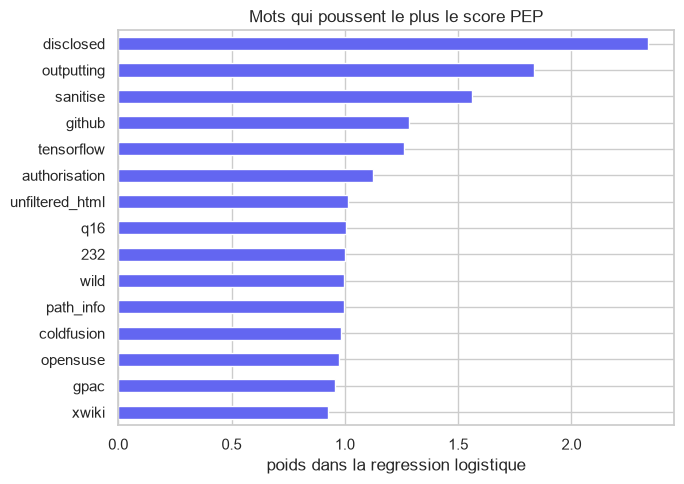

In [23]:
# Graphe : les 15 MOTS du texte au plus fort poids positif (prefixe "txt__" dans les noms de features)
mots = poids[[n for n in poids.index if n.startswith("txt__")]]
mots.index = [n.replace("txt__", "") for n in mots.index]
plt.figure(figsize=(7, 5))
mots.tail(15).plot.barh(color="#6366f1")
plt.title("Mots qui poussent le plus le score PEP")
plt.xlabel("poids dans la regression logistique")
plt.tight_layout(); plt.show()


In [24]:
# Audit anti-fuite : un mot 'traitre' (disponibilite d'exploit) figure-t-il parmi les plus predictifs ?
tabous = ["exploit", "metasploit", "poc", "github", "nuclei", "packetstorm", "cve"]
top_mots = list(mots.tail(50).index)
fuite = [m for m in top_mots if any(t in m for t in tabous)]
print("Mots tabous dans le top 50 des mots predictifs :",
      fuite if fuite else "AUCUN -> pas de fuite detectee par le texte")


Mots tabous dans le top 50 des mots predictifs : ['github']


L'audit remonte **un terme limite : `github`**. Est-ce une fuite ? Pas au sens strict (ce n'est ni
"exploit" ni "metasploit"), mais une description qui pointe vers GitHub trahit souvent l'existence d'un
dépôt (PoC, advisory) : c'est un **proxy de disponibilité / popularité**, du même type que les compteurs
qu'on a retirés (§9). La bonne réaction serait de l'**ajouter à la liste de mots exclus** du vectoriseur
pour une v2. Le reste du top, lui, est constitué de **termes de nature de vulnérabilité** (débordement,
injection, corruption mémoire...) : le modèle apprend bien des caractéristiques intrinsèques, et il reste
**explicable** poids par poids. *(C'est tout l'intérêt de l'audit : il a attrapé quelque chose.)*


## 7ter. Explication locale (SHAP) : pourquoi CETTE note ?

Les coefficients (§7bis) donnent l'image **globale** du modèle. **SHAP** donne l'explication **locale** :
pour une CVE précise, la **contribution** (+ / −) de chaque feature à *sa* note. Pour un modèle linéaire,
SHAP est **exact** (pas d'approximation) et c'est exactement ce qu'un analyste peut coller dans un ticket.


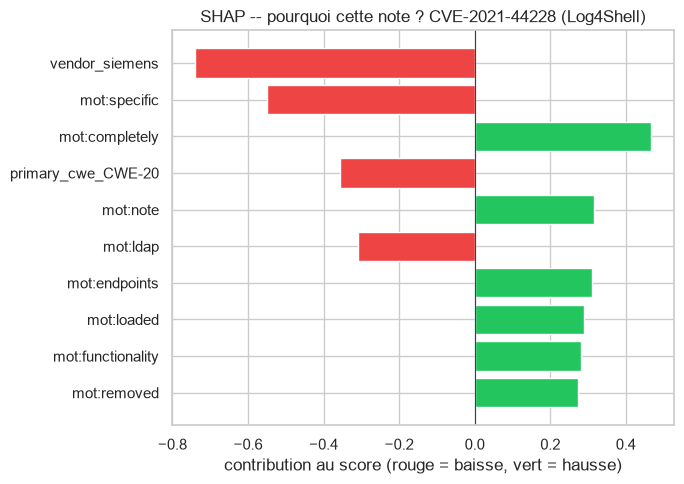

In [25]:

# On reutilise le pipeline non calibre du 7bis. LinearExplainer = SHAP exact pour un modele lineaire.
pre_shap = pipe_interpret.named_steps["pre"]
clf_shap = pipe_interpret.named_steps["clf"]
fond = pre_shap.transform(train.sample(100, random_state=RANDOM_STATE))   # arriere-plan (reference)
explainer = shap.LinearExplainer(clf_shap, fond)

# Une CVE concrete et parlante : Log4Shell
cible = donnees[donnees["cve_id"] == "CVE-2021-44228"]
valeurs = np.asarray(explainer.shap_values(pre_shap.transform(cible))).ravel()
noms_shap = pre_shap.get_feature_names_out()

# Top 10 contributions (en valeur absolue) pour CETTE CVE
idx = np.argsort(-np.abs(valeurs))[:10][::-1]
etiquettes = [str(noms_shap[i]).replace("txt__", "mot:").replace("cat__", "").replace("num__", "")
              for i in idx]
couleurs = ["#ef4444" if valeurs[i] < 0 else "#22c55e" for i in idx]
plt.figure(figsize=(7, 5))
plt.barh(etiquettes, [valeurs[i] for i in idx], color=couleurs)
plt.axvline(0, color="#334155", lw=0.8)
plt.title("SHAP -- pourquoi cette note ? CVE-2021-44228 (Log4Shell)")
plt.xlabel("contribution au score (rouge = baisse, vert = hausse)")
plt.tight_layout(); plt.show()


On lit directement, pour **cette** CVE, quels mots/critères ont poussé sa note vers le **haut** (vert)
ou vers le **bas** (rouge). C'est l'explication *par instance* qu'un analyste attend - et que l'outil du
marché (un chiffre nu) ne fournit pas. Le global (§7bis) dit *ce que le modèle a appris* ; SHAP dit
*pourquoi ce cas précis*.


## 8. Évaluer honnêtement

Un analyste n'a pas le temps de traiter toutes les CVE : il part du **haut de la liste**. La bonne question
n'est donc pas "quelle accuracy ?" mais **"parmi les k CVE que je note le plus haut, combien ont
vraiment un exploit ?"** - c'est la **precision@k**.

On la lit toujours face au **taux de base** (la proportion de positifs, ~26 % sur le test 2025) : le
rapport `precision@k / taux_base` est le **lift**, soit "combien de fois mieux que le hasard". Un bon
outil de tri a une précision élevée en tête de liste, qui décroît à mesure qu'on descend.


precision@50    = 0.98  (x3.7 le hasard)
precision@100   = 0.99  (x3.7 le hasard)
precision@500   = 0.99  (x3.7 le hasard)
precision@1000  = 0.98  (x3.7 le hasard)


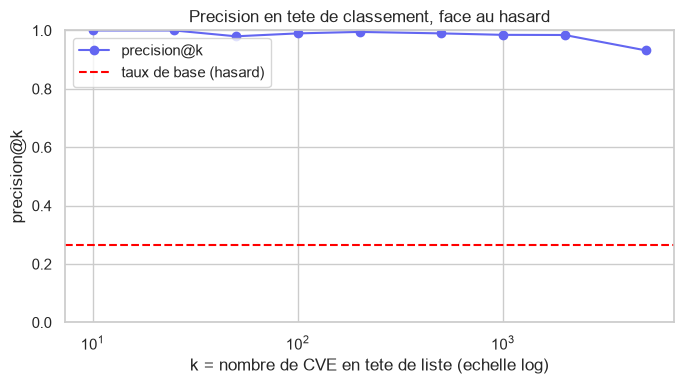

In [26]:
# precision@k = parmi les k CVE les mieux notees, quelle proportion a vraiment un exploit ?
# C'est LA metrique d'un outil de priorisation : l'analyste traite le haut de la liste d'abord.
def precision_at_k(y_vrai, scores, ks=(50, 100, 500, 1000)):

    # Indices tries par score decroissant
    ordre = np.argsort(-scores)
    y_vrai = np.asarray(y_vrai)

    # Part de positifs dans le top-k
    return {k: float(np.mean(y_vrai[ordre[:k]])) for k in ks}


# Taux de base (reference = le hasard)
taux_base = test["has_exploit"].mean()
for k, precision in precision_at_k(test["has_exploit"], proba_test).items():
    print("precision@%-5d = %.2f  (x%.1f le hasard)" % (k, precision, precision / taux_base))

# Courbe precision@k : precision en fonction de la profondeur k (echelle log), face au hasard
ks_courbe = [10, 25, 50, 100, 200, 500, 1000, 2000, 5000]
courbe = precision_at_k(test["has_exploit"], proba_test, ks=ks_courbe)
plt.figure(figsize=(7, 4))
plt.plot(list(courbe.keys()), list(courbe.values()), "o-", color="#6366f1", label="precision@k")
plt.axhline(taux_base, color="red", ls="--", label="taux de base (hasard)")
plt.xscale("log")
plt.ylim(0, 1)
plt.xlabel("k = nombre de CVE en tete de liste (echelle log)")
plt.ylabel("precision@k")
plt.title("Precision en tete de classement, face au hasard")
plt.legend()
plt.tight_layout(); plt.show()


### Les courbes ROC et précision/rappel

On a donné les AUC en chiffres ; voici les **courbes** correspondantes pour le modèle final (test 2025).


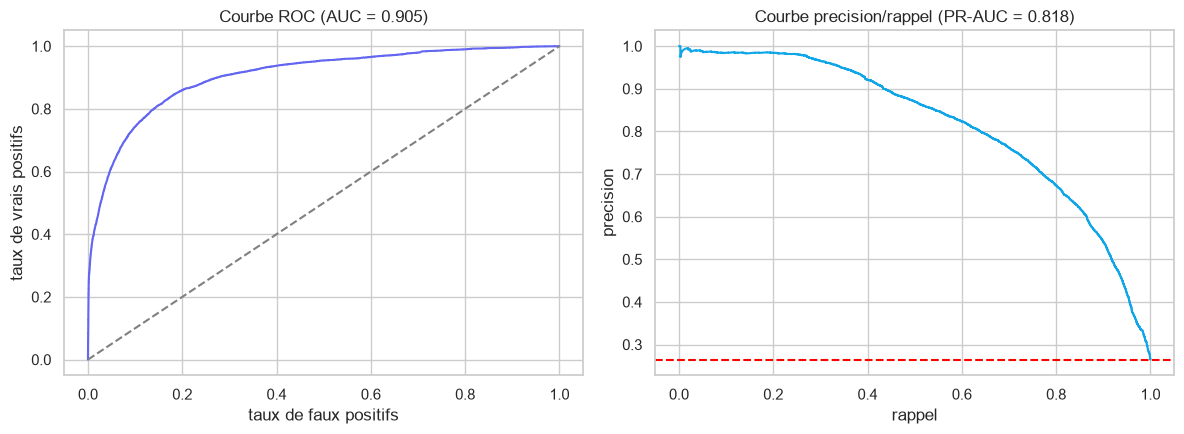

In [27]:

fpr, tpr, _ = roc_curve(test["has_exploit"], proba_test)
prec_courbe, rec_courbe, _ = precision_recall_curve(test["has_exploit"], proba_test)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
# ROC : taux de vrais positifs vs faux positifs ; la diagonale = hasard
ax[0].plot(fpr, tpr, color="#6366f1")
ax[0].plot([0, 1], [0, 1], "--", color="grey")
ax[0].set_xlabel("taux de faux positifs"); ax[0].set_ylabel("taux de vrais positifs")
ax[0].set_title("Courbe ROC (AUC = %.3f)" % roc_auc_score(test["has_exploit"], proba_test))
# Precision/rappel : la ligne rouge = taux de base (reference hasard)
ax[1].plot(rec_courbe, prec_courbe, color="#0ea5e9")
ax[1].axhline(test["has_exploit"].mean(), ls="--", color="red")
ax[1].set_xlabel("rappel"); ax[1].set_ylabel("precision")
ax[1].set_title("Courbe precision/rappel (PR-AUC = %.3f)" % average_precision_score(test["has_exploit"], proba_test))
plt.tight_layout(); plt.show()


### Décider : seuil et matrice de confusion (modèle final)

Tout ce qui suit porte sur le **modèle final calibré** (§7), évalué sur le **test 2025** (jamais vu). Le
produit est un **score**, mais si l'on doit trancher (exploit oui/non), il faut un **seuil**. Ici je prends
celui qui **maximise le F1** (compromis précision/rappel) ; en production on le choisirait selon le **coût**
relatif d'un faux positif vs d'un faux négatif.


Seuil retenu (max F1) : 0.40

               precision    recall  f1-score   support

pas d'exploit       0.91      0.90      0.90     33291
      exploit       0.73      0.74      0.74     11984

     accuracy                           0.86     45275
    macro avg       0.82      0.82      0.82     45275
 weighted avg       0.86      0.86      0.86     45275



Accuracy (.predict, seuil 0.5)    : 0.862
Accuracy (seuil 0.40, max F1)      : 0.859
Accuracy 'toujours pas d'exploit' : 0.735  (reflexe naif, utilite nulle)


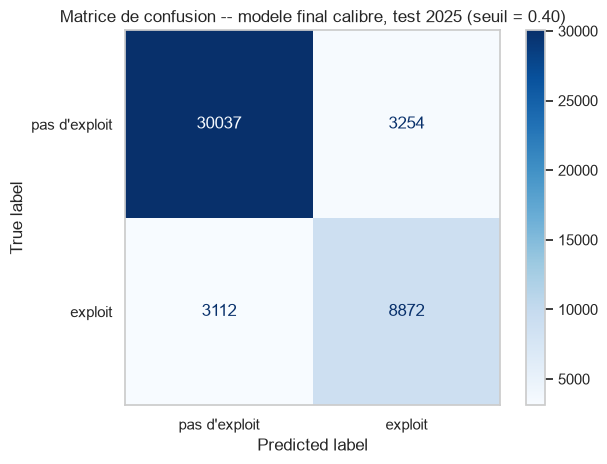

In [28]:

# Seuil qui maximise le F1 sur le test (precision_recall_curve renvoie len(seuils) = len(precision) - 1)
prec_courbe, rec_courbe, seuils = precision_recall_curve(test["has_exploit"], proba_test)
f1 = 2 * prec_courbe[:-1] * rec_courbe[:-1] / (prec_courbe[:-1] + rec_courbe[:-1] + 1e-9)
seuil = seuils[int(np.argmax(f1))]
print("Seuil retenu (max F1) : %.2f\n" % seuil)

prediction = (proba_test >= seuil).astype(int)
print(classification_report(test["has_exploit"], prediction, target_names=["pas d'exploit", "exploit"]))

# Accuracy : on la MONTRE pour comparer, meme si on ne la pilote pas (trompeuse en desequilibre).
# .predict() du modele = decision au seuil PAR DEFAUT 0.5 ; on la compare a notre seuil regle et au naif.

pred_defaut = modele_calibre.predict(test)                            # appel .predict() (seuil 0.5)
print("Accuracy (.predict, seuil 0.5)    : %.3f" % accuracy_score(test["has_exploit"], pred_defaut))
print("Accuracy (seuil %.2f, max F1)      : %.3f" % (seuil, accuracy_score(test["has_exploit"], prediction)))
print("Accuracy 'toujours pas d'exploit' : %.3f  (reflexe naif, utilite nulle)"
      % (1 - test["has_exploit"].mean()))

disp_cm = ConfusionMatrixDisplay(confusion_matrix(test["has_exploit"], prediction),
                                 display_labels=["pas d'exploit", "exploit"]).plot(
    cmap="Blues", colorbar=True, values_format="d")  # values_format="d" : chiffres entiers, pas 3e+04
disp_cm.ax_.grid(False)   # enleve le quadrillage seaborn -> 4 cases lisibles
plt.title("Matrice de confusion -- modele final calibre, test 2025 (seuil = %.2f)" % seuil)
plt.tight_layout(); plt.show()


**Sur l'accuracy.** Elle paraît flatteuse, mais **"prédire toujours ‹ pas d'exploit ›" atteint déjà
~74 %** (la classe majoritaire) pour une **utilité nulle**. C'est exactement pourquoi on ne la **pilote
pas** et qu'on juge sur **ROC-AUC / PR-AUC / precision@k**. On la montre par transparence, pas comme
critère de décision.


### Robustesse : le résultat tient-il sur d'autres années ?

Un seul test (2025) pourrait être un coup de chance. On **rejoue** l'entraînement pour trois années de test :
on apprend sur tout ce qui **précède** l'année, on teste sur l'année. Si la performance tient, c'est robuste.


test 2023 (n= 31533) : ROC=0.869  PR-AUC=0.777


test 2024 (n= 39461) : ROC=0.891  PR-AUC=0.792


test 2025 (n= 45275) : ROC=0.915  PR-AUC=0.827


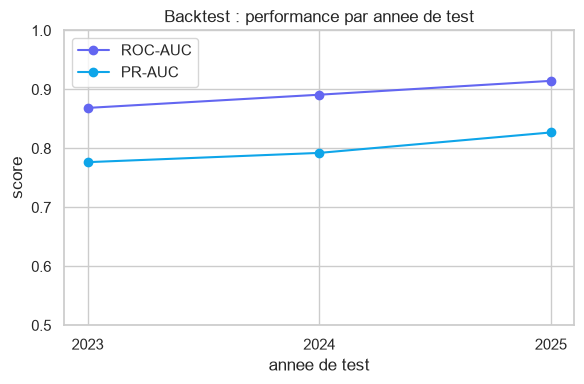

In [29]:
# Backtest : pour chaque annee de test, on (re)entraine sur les annees ANTERIEURES seulement
backtest = {}
for annee in (2023, 2024, 2025):
    tr_bt = donnees[donnees["year"] < annee]
    if len(tr_bt) > 80000:
        tr_bt = tr_bt.sample(80000, random_state=RANDOM_STATE)
    te_bt = donnees[donnees["year"] == annee]
    proba_bt = build_pipeline().set_params(clf__C=0.1).fit(tr_bt, tr_bt["has_exploit"]).predict_proba(te_bt)[:, 1]
    backtest[annee] = (roc_auc_score(te_bt["has_exploit"], proba_bt),
                       average_precision_score(te_bt["has_exploit"], proba_bt))
    print("test %d (n=%6d) : ROC=%.3f  PR-AUC=%.3f" % (annee, len(te_bt), *backtest[annee]))

annees = list(backtest)
plt.figure(figsize=(6, 4))
plt.plot(annees, [backtest[a][0] for a in annees], "o-", color="#6366f1", label="ROC-AUC")
plt.plot(annees, [backtest[a][1] for a in annees], "o-", color="#0ea5e9", label="PR-AUC")
plt.ylim(0.5, 1.0)
plt.xticks(annees)
plt.xlabel("annee de test")
plt.ylabel("score")
plt.title("Backtest : performance par annee de test")
plt.legend()
plt.tight_layout(); plt.show()


La performance est **stable** - et monte même avec plus de données d'entraînement (~0,87 -> ~0,89 ->
~0,91). Le résultat de 2025 n'est donc pas un coup de chance sur une seule année.

*Nuance :* ce backtest 2025 (~0,915) est un peu **au-dessus** du 0,905 du §7 - normal, il utilise un pipeline
**non calibré** et un train **sous-échantillonné** (banc d'essai rapide). Le chiffre de référence du modèle
livré reste celui du §7 (**calibré** : ROC 0,905).


En tête de liste, la précision **écrase le taux de base** (lift x3-4) : l'analyste qui traite d'abord
mes CVE les mieux notées tombe bien plus souvent sur de vrais exploits. **C'est ça, la valeur d'un outil de
priorisation** - pas l'accuracy. Elle reste élevée assez profond, puis décroît : normal, on finit par
"épuiser" les vrais positifs.

**Ce que je ne prétends pas.** Je prédis l'*existence* d'un exploit, pas l'exploitation réelle observée :
sur la tâche propre d'EPSS (attaques constatées à 30 jours), mon score n'est **pas** additif. Sa valeur est
**descriptive** - un tri indépendant, calibré et explicable - surtout utile sur les ~94 % de CVE qu'EPSS
note bas et laisse sans signal fort. C'est un **complément** à EPSS, jamais un remplaçant.


## 8bis. La valeur ajoutée : le point aveugle d'EPSS

EPSS répond à une **autre question** (une CVE sera-t-elle *attaquée* sous 30 jours ?) et, de fait, note
**bas l'immense majorité** des CVE - sur le test 2025, la médiane EPSS est ~0,003. Beaucoup de CVE qui ont
pourtant un **exploit public existant** se retrouvent dans cette zone basse : c'est le **point aveugle**
d'EPSS.

La promesse de PEP : **y voir clair**. Je récupère l'EPSS (score de référence, *jamais* utilisé comme
feature) et je regarde, parmi les CVE qu'EPSS note très bas, si PEP retrouve quand même les vrais exploits.


In [30]:
# Table de comparaison : par CVE de test, le vrai label, le score PEP (notre modele) et l'EPSS.
# Rappel : l'EPSS est une colonne gardee A PART, jamais utilisee comme feature du modele.
benchmark = test[["cve_id", "has_exploit", "epss"]].copy()
benchmark["pep"] = proba_test

# Cohorte "aveugle d'EPSS" : les CVE qu'EPSS note tres bas (< 0.01)
cohorte = benchmark[benchmark["epss"] < 0.01]
base_cohorte = cohorte["has_exploit"].mean()
print("Cohorte EPSS < 0.01 : %d CVE (%.0f%% du test)" % (len(cohorte), 100 * len(cohorte) / len(benchmark)))
print("  dont %d ont REELLEMENT un exploit, mais sont notees basses par EPSS" % int(cohorte["has_exploit"].sum()))
print("  taux d'exploit dans la cohorte : %.1f%%" % (100 * base_cohorte))


Cohorte EPSS < 0.01 : 42448 CVE (94% du test)
  dont 10266 ont REELLEMENT un exploit, mais sont notees basses par EPSS
  taux d'exploit dans la cohorte : 24.2%


### Le point aveugle, en image

Chaque point est une CVE de test : **EPSS en abscisse, PEP en ordonnée**, colorée selon qu'elle a un
exploit réel. La **zone de valeur** est en **haut à gauche** - EPSS bas, PEP haut : des CVE qu'un tri par
EPSS laisserait de côté, mais que PEP remonte... et qui ont bel et bien un exploit.


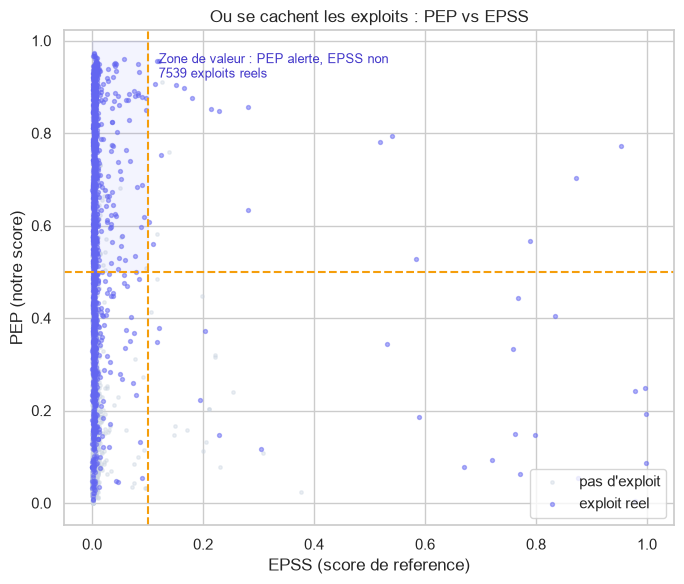

In [31]:

# Quadrant PEP (y) vs EPSS (x) : ou se cachent les exploits reels ? (echantillon pour la lisibilite)
viz = benchmark.sample(6000, random_state=RANDOM_STATE)
plt.figure(figsize=(7, 6))
plt.scatter(viz.loc[viz.has_exploit == 0, "epss"], viz.loc[viz.has_exploit == 0, "pep"],
            s=6, c="#cbd5e1", alpha=0.4, label="pas d'exploit")
plt.scatter(viz.loc[viz.has_exploit == 1, "epss"], viz.loc[viz.has_exploit == 1, "pep"],
            s=8, c="#6366f1", alpha=0.5, label="exploit reel")

# Seuils : EPSS bas (< 0.1) et PEP haut (> 0.5) -> la zone de valeur est en haut a gauche
plt.axvline(0.1, color="#f59e0b", ls="--")
plt.axhline(0.5, color="#f59e0b", ls="--")
plt.gca().add_patch(Rectangle((0, 0.5), 0.1, 0.5, color="#6366f1", alpha=0.07))

# Nombre d'exploits reels dans la zone de valeur (calcule sur TOUT le test, pas l'echantillon)
n_zone = int(benchmark[(benchmark.epss < 0.1) & (benchmark.pep > 0.5)].has_exploit.sum())
plt.text(0.12, 0.92, "Zone de valeur : PEP alerte, EPSS non\n%d exploits reels" % n_zone,
         fontsize=9, color="#4338ca")
plt.xlabel("EPSS (score de reference)")
plt.ylabel("PEP (notre score)")
plt.title("Ou se cachent les exploits : PEP vs EPSS")
plt.legend(loc="lower right")
plt.tight_layout(); plt.show()


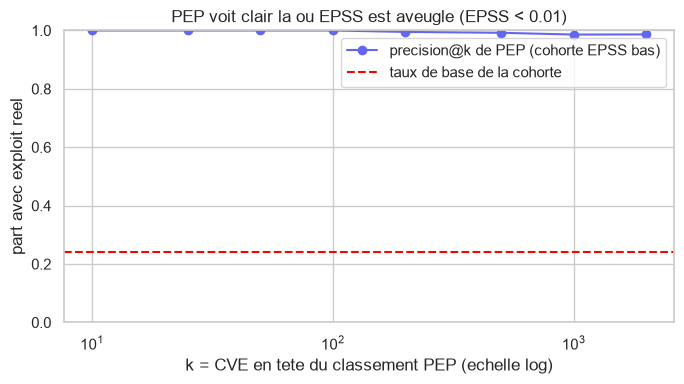

In [32]:
# PEP retrouve-t-il ces exploits ? precision@k en triant la cohorte aveugle par score PEP
classement = cohorte.sort_values("pep", ascending=False)["has_exploit"].to_numpy()
ks = [10, 25, 50, 100, 200, 500, 1000, 2000]
precisions = [classement[:k].mean() for k in ks]

plt.figure(figsize=(7, 4))
plt.plot(ks, precisions, "o-", color="#6366f1", label="precision@k de PEP (cohorte EPSS bas)")
plt.axhline(base_cohorte, color="red", ls="--", label="taux de base de la cohorte")
plt.xscale("log")
plt.ylim(0, 1)
plt.xlabel("k = CVE en tete du classement PEP (echelle log)")
plt.ylabel("part avec exploit reel")
plt.title("PEP voit clair la ou EPSS est aveugle (EPSS < 0.01)")
plt.legend()
plt.tight_layout(); plt.show()


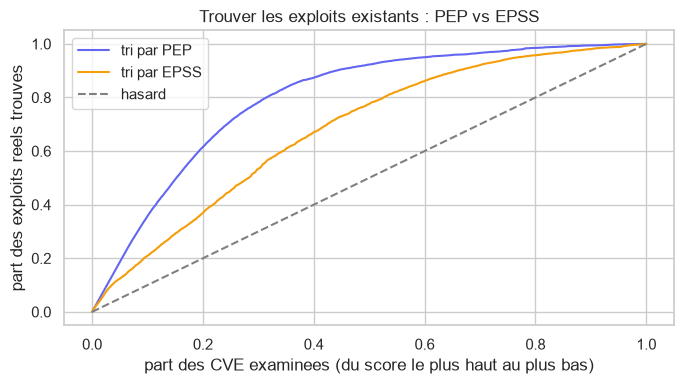

In [33]:
# Vue tete-a-tete : en parcourant les CVE du score le plus haut au plus bas, quelle part des exploits
# REELS capture-t-on ? (courbe de gain). On compare le tri par PEP et le tri par EPSS.
def courbe_gain(scores):
    ordre = np.argsort(-scores)
    y_ordonne = benchmark["has_exploit"].to_numpy()[ordre]
    return np.cumsum(y_ordonne) / y_ordonne.sum()


part_examinee = np.arange(1, len(benchmark) + 1) / len(benchmark)
plt.figure(figsize=(7, 4))
plt.plot(part_examinee, courbe_gain(benchmark["pep"].to_numpy()), color="#6366f1", label="tri par PEP")
plt.plot(part_examinee, courbe_gain(benchmark["epss"].to_numpy()), color="#f59e0b", label="tri par EPSS")
plt.plot([0, 1], [0, 1], "--", color="grey", label="hasard")
plt.xlabel("part des CVE examinees (du score le plus haut au plus bas)")
plt.ylabel("part des exploits reels trouves")
plt.title("Trouver les exploits existants : PEP vs EPSS")
plt.legend()
plt.tight_layout(); plt.show()


### Un temps d'avance (indicatif)

PEP est un signal **à T0** : il est disponible dès la publication de la CVE, à partir de ses seules
caractéristiques intrinsèques - sans attendre qu'un exploit soit observé. Pour les CVE dont l'exploit
paraît **après** la publication, il l'**anticipe** donc.


In [34]:
# Lead time : pour les CVE exploitees, delai entre publication de la CVE et publication de l'exploit
exploites = test[test.has_exploit == 1].copy()
delai = pd.to_numeric(exploites["days_to_exploit"], errors="coerce")
part_apres = (delai > 0).mean()
print("Exploit publie APRES la CVE : %.0f%% des CVE exploitees" % (100 * part_apres))
print("  pour celles-ci, PEP (dispo a T0) anticipe l'exploit d'une mediane de %.0f jours"
      % delai[delai > 0].median())
print("Les %.0f%% restantes ont deja un exploit au moment de la CVE : PEP y est alors descriptif"
      % (100 * (1 - part_apres)))


Exploit publie APRES la CVE : 8% des CVE exploitees
  pour celles-ci, PEP (dispo a T0) anticipe l'exploit d'une mediane de 26 jours
Les 92% restantes ont deja un exploit au moment de la CVE : PEP y est alors descriptif


*Honnêteté :* la **majorité des exploits précèdent la CVE** - l'anticipation ne concerne donc qu'une
minorité de cas. C'est la leçon de l'état de l'art (*Expected Exploitability*) : les features à T0 sont de
**faibles** prédicteurs du *délai*, et la vraie valeur temporelle viendrait d'un modèle de **survie**
(ouvertures §10). Ici le lead time est un **bonus** ; l'apport principal reste la **visibilité** sur le
point aveugle d'EPSS.


**Lecture.** Parmi les CVE qu'EPSS note < 0,01 (~ 94 % du test), **~10 000 ont pourtant un exploit
réel** - le point aveugle. Or le haut du classement PEP y est **quasi pur** (precision@k ~ 1, soit ~x4 le
taux de la cohorte) : PEP surface exactement ces exploits qu'EPSS laisse dans le bruit. La **courbe de
gain** le confirme - pour retrouver les exploits *existants*, trier par PEP domine largement trier par
EPSS.

**Honnêteté.** Ce n'est **pas** "battre EPSS" : EPSS répond à une autre question (attaque réelle à 30 j)
et gagnerait sur *sa* tâche, qu'on ne mesure pas ici faute de télémétrie. Ce que je montre, c'est la
**complémentarité** : un signal indépendant et calibré qui éclaire précisément les ~94 % de CVE qu'EPSS
classe bas.


### Contrôle : et sur KEV (exploitation confirmée) ?

Test de la **tâche propre d'EPSS**, hors de notre cible : classer les CVE de la liste **KEV** (exploitation
*confirmée* par la CISA, très rare). On compare PEP, EPSS, et une **combinaison apprise** des deux.


In [35]:

# KEV = exploitation CONFIRMEE (rare). On note le pouvoir de classement de chaque signal sur is_kev.
y_kev = test["is_kev"].to_numpy()
print("KEV dans le test :", int(y_kev.sum()), "/", len(y_kev))

# Combinaison APPRISE [EPSS, PEP] -> is_kev, en cross-validation (pas d'overfit sur le test)
combo_appris = cross_val_predict(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    np.c_[test["epss"].to_numpy(), proba_test], y_kev,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE), method="predict_proba")[:, 1]

for nom, score in [("EPSS seul", test["epss"].to_numpy()), ("PEP seul", proba_test),
                   ("EPSS + PEP (appris)", combo_appris)]:
    print("ROC(is_kev) %-22s = %.3f" % (nom, roc_auc_score(y_kev, score)))


KEV dans le test : 183 / 45275
ROC(is_kev) EPSS seul              = 0.971
ROC(is_kev) PEP seul               = 0.537
ROC(is_kev) EPSS + PEP (appris)    = 0.954


**Lecture honnête.** Sur KEV, **EPSS domine (~ 0,97)** - c'est sa tâche (exploitation observée) - et
**PEP est quasi au hasard (~ 0,54)** ; les combiner **n'apporte rien** (~ 0,95). C'est **attendu et sain** :
PEP prédit l'**existence** d'un exploit, pas l'**exploitation**. Ce contrôle prouve deux choses : (1) PEP
n'est **pas** une copie d'EPSS (sinon il classerait bien KEV) ; (2) sa valeur est **ailleurs** - sur
l'existence, là où EPSS est aveugle (le point aveugle ci-dessus). On **ne prétend donc pas** enrichir EPSS
sur SA tâche ; on est **complémentaire**, sur une **autre** question.


## 8ter. Contrôle live : les CVE de 2026 (hold-out non mûri)

Le backtest ci-dessus s'arrête à 2025. Or **l'année 2026 existe dans les données** (32 725 CVE jusqu'au
`ref_date`), mais elle a été **volontairement exclue** de l'entraînement *et* des métriques officielles :
ses fiches sont **immatures** et surtout ses labels sont **censurés à droite** - une CVE publiée en 2026
n'a **pas encore eu le temps** d'obtenir un exploit, donc son `has_exploit = 0` est en partie un
"pas encore", pas un "jamais".

C'est justement pour cela qu'un **contrôle live** est intéressant : que donne le modèle sur des données
**fraîches**, jamais vues, dans les conditions réelles de production ? On score 2026 avec le **même
pipeline que le backtest** (non calibré, `C=0,1`, entraîné sur les années antérieures) et on compare à 2025.


2025 (n= 45275, %positifs=0.265) : ROC=0.915  PR-AUC=0.827  Brier=0.110  prec@100=0.98  prec@1000=0.98


2026 (n= 32725, %positifs=0.253) : ROC=0.838  PR-AUC=0.696  Brier=0.163  prec@100=0.97  prec@1000=0.96


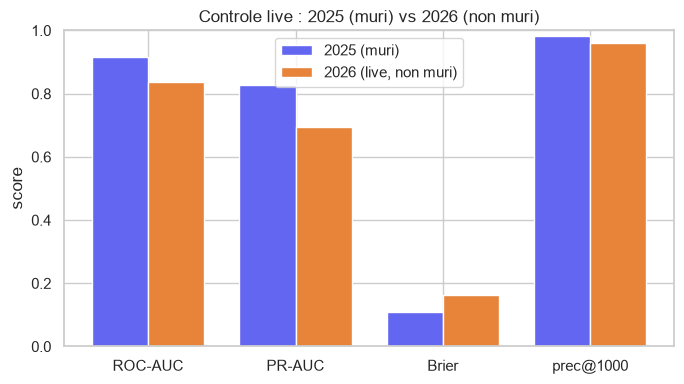

In [36]:
# Controle live : on evalue 2025 (muri) et 2026 (non muri) avec le meme protocole que le backtest.
# 2026 est EXCLU des metriques officielles (censure a droite) ; ici c'est un test de realite, pas un score.
live = {}
for annee in (2025, 2026):
    tr_lv = donnees[donnees["year"] < annee]
    if len(tr_lv) > 80000:
        tr_lv = tr_lv.sample(80000, random_state=RANDOM_STATE)
    te_lv = donnees[donnees["year"] == annee]
    p_lv = build_pipeline().set_params(clf__C=0.1).fit(tr_lv, tr_lv["has_exploit"]).predict_proba(te_lv)[:, 1]
    y_lv = te_lv["has_exploit"].to_numpy()
    ordre = np.argsort(-p_lv)
    live[annee] = {
        "n": len(te_lv), "pos": float(y_lv.mean()),
        "roc": roc_auc_score(y_lv, p_lv), "pr": average_precision_score(y_lv, p_lv),
        "brier": brier_score_loss(y_lv, p_lv),
        "p100": float(y_lv[ordre[:100]].mean()), "p1000": float(y_lv[ordre[:1000]].mean()),
    }
    r = live[annee]
    print("%d (n=%6d, %%positifs=%.3f) : ROC=%.3f  PR-AUC=%.3f  Brier=%.3f  prec@100=%.2f  prec@1000=%.2f"
          % (annee, r["n"], r["pos"], r["roc"], r["pr"], r["brier"], r["p100"], r["p1000"]))

# Graphe : 2025 muri vs 2026 non muri (Brier : plus bas = mieux)
noms = ["ROC-AUC", "PR-AUC", "Brier", "prec@1000"]
v25 = [live[2025][k] for k in ("roc", "pr", "brier", "p1000")]
v26 = [live[2026][k] for k in ("roc", "pr", "brier", "p1000")]
x = np.arange(len(noms)); w = 0.38
plt.figure(figsize=(7, 4))
plt.bar(x - w/2, v25, w, color="#6366f1", label="2025 (muri)")
plt.bar(x + w/2, v26, w, color="#e8833a", label="2026 (live, non muri)")
plt.xticks(x, noms); plt.ylim(0, 1); plt.ylabel("score")
plt.title("Controle live : 2025 (muri) vs 2026 (non muri)")
plt.legend(); plt.tight_layout(); plt.show()


**Lecture honnête.** Sur les données fraîches de 2026, la performance **baisse** : ROC-AUC 0,915 ->
**0,838**, PR-AUC 0,827 -> **0,696**, et le Brier **empire** de 0,110 à **0,163**. En revanche, le **haut du
classement tient remarquablement** : `prec@100` 0,98 -> **0,97**, `prec@1000` 0,98 -> **0,96**. Trois lectures,
qui vont dans le même sens :

1. **Dérive temporelle** : le vocabulaire des CVE de 2026 diffère de celui du train (<= 2025).
2. **Moins de fuite temporelle** : les fiches 2026 sont **immatures** (souvent `Received` / `Awaiting
   Analysis`), donc les proxys temporels qui aidaient sur 2025 (cf. §10, le token `disclosed`) sont **moins
   informatifs**. Autrement dit, **~0,84 est sans doute plus proche de la vraie performance "à T0"** que
   le ~0,92 mesuré sur 2025.
3. **Censure à droite** : une partie des "négatifs" de 2026 auront un exploit **plus tard** -> ces
   chiffres sont **pessimistes** (surtout PR-AUC et Brier). Le taux de positifs reste pourtant proche de
   2025 (~0,25) : cohérent avec "la plupart des exploits existent déjà à T0" (§8bis).

Ce qui se dégrade le plus, ce n'est donc **pas** le tri des tout premiers (`prec@100` reste ~0,97 : le
*ranking* du sommet est robuste) mais **la calibration** (Brier +48 %) et le **classement de la classe rare**
(PR-AUC −0,13). Traduction produit : on peut continuer à faire **confiance au haut de la liste**, mais les
**probabilités absolues se périment** -> monitoring PSI/Brier et **recalibrage périodique** (§12). C'est
exactement le garde-fou qu'un modèle en production doit avoir.


## 9. Les itérations et les résultats négatifs

La partie dont je suis le plus fier : **mesurer avant d'ajouter, savoir dire non.** Chaque idée ci-dessous
a été *testée*, puis gardée ou écartée **sur preuve chiffrée**, pas à l'intuition.

Je me donne un petit banc d'essai : entraîner une régression logistique sur un jeu de colonnes donné et
lire son ROC / PR-AUC sur le test temporel (2025). C'est un banc **simplifié** (encodage ordinal, pas de
texte) : ce qui compte est l'**écart** entre variantes, pas la valeur absolue.


In [37]:

# Banc d'essai : entraine une LogReg sur les colonnes (cat, num) donnees, renvoie (ROC, PR-AUC) sur 2025
def essai(colonnes_cat, colonnes_num):

    # Categorielles en entiers (fit sur le train seul), numeriques en log1p
    encodeur = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_train = np.c_[encodeur.fit_transform(train[colonnes_cat].astype(str)),
                    np.log1p(train[colonnes_num].to_numpy(float))]
    X_test = np.c_[encodeur.transform(test[colonnes_cat].astype(str)),
                   np.log1p(test[colonnes_num].to_numpy(float))]

    # Mise a l'echelle (fit sur le train) puis entrainement
    scaler = StandardScaler().fit(X_train)
    modele = LogisticRegression(max_iter=3000, class_weight="balanced").fit(
        scaler.transform(X_train), train["has_exploit"])
    proba = modele.predict_proba(scaler.transform(X_test))[:, 1]
    return roc_auc_score(test["has_exploit"], proba), average_precision_score(test["has_exploit"], proba)


# Reference : toutes les features structurees retenues
roc_ref, pr_ref = essai(CAT_FEATURES, NUM_FEATURES)
print("Reference (features retenues) : ROC=%.3f  PR-AUC=%.3f" % (roc_ref, pr_ref))


Reference (features retenues) : ROC=0.770  PR-AUC=0.627


### Test 1 - Les compteurs de popularité (le bug Log4Shell)

Idée intuitive : "une CVE très référencée ou touchant beaucoup de produits doit être plus exploitée".
J'ajoute `n_references`, `n_cpe_versions`, `n_cpe_match`. **Test :**


In [38]:
# Correlation de chaque compteur avec le label : quasi nulle
compteurs = ["n_references", "n_cpe_versions", "n_cpe_match"]
for col in compteurs:
    print("corr(%-15s, has_exploit) = %+.3f" % (col, donnees[col].fillna(0).corr(donnees["has_exploit"])))

# Ablation : les ajouter au modele change-t-il quelque chose ?
roc_avec, pr_avec = essai(CAT_FEATURES, NUM_FEATURES + compteurs)
print("\nSANS compteurs : ROC=%.3f  PR-AUC=%.3f" % (roc_ref, pr_ref))
print("AVEC compteurs : ROC=%.3f  PR-AUC=%.3f" % (roc_avec, pr_avec))

# Le piege : ce sont des outliers extremes : fort levier sur un modele lineaire, pour ~0 signal
log4shell_cpe = donnees.loc[donnees.cve_id == "CVE-2021-44228", "n_cpe_versions"].iloc[0]
print("\nLog4Shell n_cpe_versions = %d  vs mediane du corpus = %d"
      % (log4shell_cpe, donnees["n_cpe_versions"].median()))


corr(n_references   , has_exploit) = -0.022
corr(n_cpe_versions , has_exploit) = -0.051
corr(n_cpe_match    , has_exploit) = -0.045



SANS compteurs : ROC=0.770  PR-AUC=0.627
AVEC compteurs : ROC=0.783  PR-AUC=0.589

Log4Shell n_cpe_versions = 1810  vs mediane du corpus = 3


Corrélation **~0** ; ajoutés au modèle, le ROC bouge à peine tandis que le **PR-AUC se dégrade**
(0,63 -> 0,59) - **aucun gain fiable**. Pire : ce sont des **outliers extrêmes** (Log4Shell = 1810 vs
médiane 3) qui prennent un **poids parasite** dans un modèle linéaire et faussaient le classement de CVE
célèbres. **Décision : retirés du modèle** (gardés pour l'EDA seulement).


### Test 2 - Regrouper les CWE en familles

~700 types de failles (CWE), c'est beaucoup. Idée : les regrouper en grandes familles (`cwe_family`) pour
aider le modèle à généraliser. **Test :** ajouter cette colonne aux catégorielles.


In [39]:
# On ajoute cwe_family aux categorielles et on remesure
roc_fam, pr_fam = essai(CAT_FEATURES + ["cwe_family"], NUM_FEATURES)
print("SANS familles CWE : ROC=%.3f  PR-AUC=%.3f" % (roc_ref, pr_ref))
print("AVEC familles CWE : ROC=%.3f  PR-AUC=%.3f" % (roc_fam, pr_fam))


SANS familles CWE : ROC=0.770  PR-AUC=0.627
AVEC familles CWE : ROC=0.770  PR-AUC=0.627


Gain **négligeable** : l'information est déjà captée par `primary_cwe` et les mots-clés. Une feature
de plus pour rien = complexité inutile. **Décision : écartée.**


### Test 3 - Présence de mots (binaire) vs TF-IDF

Pour le texte, le réflexe classique est TF-IDF (pondérer par la rareté). Je le compare à la simple
**présence** de mots (binaire). **Test :** un modèle texte seul, avec l'une puis l'autre vectorisation.


In [40]:

# Meme modele texte-seul, deux vectorisations a comparer
for nom, vectoriseur in {"presence (binaire)": CountVectorizer(binary=True, min_df=100),
                         "TF-IDF": TfidfVectorizer(min_df=100)}.items():
    X_train = vectoriseur.fit_transform(train["description"])
    X_test = vectoriseur.transform(test["description"])
    modele = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_train, train["has_exploit"])
    proba = modele.predict_proba(X_test)[:, 1]
    print("%-19s ROC=%.3f  PR-AUC=%.3f" % (nom, roc_auc_score(test["has_exploit"], proba),
                                           average_precision_score(test["has_exploit"], proba)))


presence (binaire)  ROC=0.904  PR-AUC=0.809


TF-IDF              ROC=0.913  PR-AUC=0.826


TF-IDF est ici **marginalement** meilleur (~+0,01 ROC), un écart négligeable. Je garde quand même
la **présence binaire** : ce qui compte c'est *qu'un terme technique soit présent*, pas sa fréquence dans
une description courte ; et le binaire est bien plus **interprétable** (un poids = "ce mot présent pousse
le score de tant") et aligné avec la littérature (Expected Exploitability). Un gain de 0,01 ne justifie
pas de perdre la lisibilité des poids. **Décision assumée : binaire.**


> Rappel du **signal gardé** : le texte (démontré en §6, ROC ~0,77 -> ~0,91). C'est mon *moat*. Ici je
> me concentre sur ce que j'ai **écarté**.

**Une piste écartée côté label.** J'ai aussi testé les *sources* d'exploit (sur des données à
drapeaux par source) : ajouter "n'importe quel dépôt GitHub mentionnant la CVE" **dégradait** la qualité
(bruit) -> source écartée, 5 sources fiables retenues.

**Le plafond.** Après avoir poussé features, modèles et sources, ma limite n'est **ni le modèle ni les
features**, mais le **label** : une CVE publiée il y a deux semaines n'a en général *pas encore* d'exploit
catalogué - aucune source, même commerciale, ne peut le deviner (la censure, §3b). Un modèle sur features
intrinsèques plafonne donc ; sa valeur reste réelle mais **bornée**, et surtout **descriptive** (quelles
CVE portent un exploit) plutôt que divinatoire.


## 10. Limites et ouvertures

**Limites, assumées :** je prédis l'*existence* d'un exploit (pas l'attaque réelle) ; label **censuré**
sur le récent ; léger **biais de popularité**.

**Ouvertures :**
- **Features qui varient dans le temps** - LE levier n°1, et il est gratuit. C'est la réponse directe à
  mon résultat le plus sévère (valeur prédictive ~nulle, PR-AUC 0,04) et la leçon d'Expected Exploitability :
  l'intrinsèque à T0 ne suffit pas. On donnerait au modèle des *trajectoires* sur les premiers jours :
  historique EPSS (CSV quotidien de FIRST -> pente/accélération), activité des dépôts PoC (PoC-in-GitHub +
  API GitHub), accrual de références (la *dérivée*, pas le total), scan réel (GreyNoise community).
- **Analyse de survie** (modèle de Cox) : prédire le *délai avant exploit* plutôt qu'un oui/non à 90
  jours -> traite proprement la censure, et bien plus actionnable. C'est *le modèle* que les features
  temporelles ci-dessus viennent *nourrir*.
- **Conformal prediction** : livrer un *intervalle calibré* par CVE + un franc "je ne sais pas" quand le
  modèle est incertain, plutôt qu'une note seule - cohérent avec l'exigence de ne jamais survendre.
- **Embeddings de phrases légers** (type MiniLM, sans GPU) pour capter les synonymes - à évaluer en
  ablation (les unigrammes tiennent souvent la comparaison sur cette tâche).
- **SHAP -> action** : traduire l'explication locale en remédiation suggérée (règle WAF temporaire).
- **Dérive à noyau (MMD)** : compléter le PSI (univarié, sur le score) par un test à deux échantillons à
  noyau (*Maximum Mean Discrepancy*) sur les **features** - détection **multivariée** et statistiquement
  principielle de la dérive d'entrée, plus sensible que le PSI binné. Nuance : il capte la dérive de
  *covariables*, pas de *concept* (celle-ci reste couverte par le Brier glissant, qui exige des labels).

**En une phrase :** un signal de priorisation *indépendant, calibré et explicable*, dont j'ai mesuré
honnêtement la valeur **et** les limites.


## 11. De l'entraînement au service (mise en production)

Le notebook montre la **partie ML** ; en pratique elle est industrialisée en quelques modules Python, avec
**le même code d'extraction** (`features_feed.py`) à l'entraînement **et** au scoring -> **aucun décalage
train/serve**.

**Les modules (`src/cve_exploit/`)** - même séparation que le canon *pipeline / preprocessing / model /
utils / main*, en plus granulaire (mapping complet dans le `README`) :
- `features_feed.py` - JSON -> features (source unique, partagée) ; `dataset.py` - construit le Parquet.
- `train.py` - `build_pipeline()` (ColumnTransformer + LogReg) + entraînement + calibration ->
  `models/model.joblib` ; `score.py` - score **une** CVE (JSON -> PEP **+ `reliability`**).
- `batch.py` / `enrich.py` - scoring de masse ; `utils.py` - **métriques + visualisation** ;
  `main.py` - **entrée CLI unique**.
- `api.py` - service **FastAPI** ; `db.py` - Postgres ; `monitor.py` - dérive (PSI + Brier) ;
  `retrain.py` - **champion / challenger**.

**En ligne de commande** - via le point d'entrée unique `main.py` :


In [41]:
# CLI : un point d'entree unique (main.py) qui dispatche vers les sous-commandes
# uv run python -m cve_exploit.main train               # entraine + calibre -> models/model.joblib
# uv run python -m cve_exploit.main score --cve x.json  # score UNE CVE (JSON) -> PEP
# uv run python -m cve_exploit.main batch               # score toute la base -> parquet
# uv run python -m cve_exploit.main enrich --in b.tar.gz --out b_pep.tar.gz
# uv run python -m cve_exploit.main monitor             # metriques de derive du jour


**En service (API REST)** - une CVE à la demande, ou 1 à 20 d'un coup :

In [42]:
# API REST (FastAPI)
# GET  /score/{cve_id}   ->  { pep, reliability, model_version, signals }
# POST /enrich           ->  les memes JSON, enrichis de specific.pep = {score, reliability, ...}


**Déploiement (Docker)** - tout se lance en une commande ; le `model.joblib` est **monté en volume**
(hors image) -> on peut ré-entraîner et **recharger** sans reconstruire l'image.

In [43]:
# Deploiement : db (Postgres) + api (:8000) + front (:5173)
# docker compose up --build


**Monitoring de dérive.** À chaque nouveau bundle, `monitor.py` : (1) score le bundle avec le modèle
courant ; (2) historise **seulement les changements** (`pep_current` = état courant, `pep_history` = diff
daté) ; (3) calcule le **PSI** (distribution des PEP du jour vs référence figée à l'entraînement) -> dérive
**sans labels**, immédiate ; (4) calcule le **Brier glissant** sur la cohorte **mûrie** (publiée il y a
>= 90 j, vérité connue) -> dérive de **performance**, en différé ; (5) écrit une ligne `drift_daily` et, si un
seuil est franchi, une `drift_alert` + un **flag de ré-entraînement** (*alerte-seule* : l'humain lance
`retrain.py`). Idempotent par jour, et **rejouable** sur une plage de dates.

**L'application (React).** Le front (`frontend/`, React + TanStack Router/Table + ECharts) lit l'API et
offre trois onglets : **Enrich** (coller 1 à 20 CVE -> **jauge PEP** + signaux + JSON enrichi),
**Analysis** (la valeur : angle mort d'EPSS, top mouvements du PEP, nuage PEP↔EPSS) et **Drift** (séries
**PSI / Brier** dans le temps + alertes ouvertes).

**Tout réinitialiser (repartir de zéro)** - `--reset` vide les tables (`pep_current`, `pep_history`,
`drift_daily`, `drift_alert`) ; `down -v` efface le volume de la base :


In [44]:
# Reset complet, puis rejeu de l'historique jour par jour :
# docker compose down -v                                    # stoppe tout + supprime la base (volume)
# uv run python -m cve_exploit.main train                   # re-entraine -> models/model.joblib
# docker compose up --build -d                              # relance db + api + front
# uv run python -m cve_exploit.main monitor --reset --day 2026-06-23 --in 23-06-2026/cve_threat_intel.tar.gz
# uv run python -m cve_exploit.main monitor        --day 2026-06-24 --in 24-06-2026/cve_threat_intel.tar.gz
# ... un appel par bundle date


**Partage.** Le dépôt Git contient toute la pipeline (extraction -> dataset -> entraînement -> service +
monitoring + front). **Ce notebook en est la partie ML, auto-portante** : il rejoue le raisonnement de bout
en bout (des JSON au modèle calibré) et sert de documentation vivante du coeur du système.


## 11bis. Savoir dire "je ne sais pas" (fiabilité de chaque note)

Avant de scorer, on vérifie qu'il y a **assez d'information** dans la fiche. Chaque note porte un
niveau de fiabilité `reliability` à **trois** valeurs :
- **`ok`** - fiche complète, note fiable ;
- **`low`** - fiche **immature** (pas encore analysée par la NVD, ou squelettique) -> note affichée
  mais **"estimation peu fiable"** ; c'est justement la zone où le modèle est le plus biaisé (cf. §10) ;
- **`insufficient`** - fiche **sans description, ni CVSS, ni CWE** (~1,3 % des CVE, souvent
  réservées/rejetées) -> **on ne renvoie pas de note** (`pep = null`) et on répond
  *"pas assez d'informations pour juger"*.

Le critère filtre sur la **cause** (fiche non analysée / vide), **pas sur l'âge** (un seuil en jours
raterait les vieilles fiches restées squelettiques). Livrer un chiffre inventé sur une fiche vide serait
pire que se taire : un score de priorisation doit **assumer son incertitude** - c'est ce qui le rend
défendable auprès d'un analyste. *(Implémentation : `features_common.has_enough_info` + `immaturity_reasons`,
partagées par `score.py`, `batch.py`, `enrich.py` et l'API -> 0 skew.)*


## 12. Déploiement - architecture de bout en bout

Le §11 a listé les modules ; ici la **vue d'ensemble** : les deux chemins (entraînement *offline* /
service *online*), la topologie des conteneurs, le **versionnage** de l'artefact, et comment on
**remplace** un modèle sans casser le service.

*Honnêteté (périmètre).* Tout tourne en **local via `docker compose`** (démo reproductible) : pas
d'hébergement cloud, d'autoscaling ni d'authentification - **hors périmètre** de l'exercice. Ce qui suit
décrit ce qui est **réellement** dans le dépôt.


### 12.1 Deux chemins : offline (entraînement) / online (service)

Le même code d'extraction sert des deux côtés - c'est la garantie **0 skew** train/serve.

```
        OFFLINE  (batch, periodique)                      ONLINE  (a la demande)
        ============================                      ======================

  cve_threat_intel/  (369 677 JSON)
          |
          |  features_feed.py  <=====  MEME CODE  =====>  features_feed.py
          |  (extraction JSON -> features, partagee)
          v                                                        ^
  dataset.py --> data/dataset.parquet                              |
          |                                                models/model.joblib
          v                                                (charge au demarrage)
  train.py --> models/model.joblib  ---------------->  +-----------+-----------+
          +--> models/model_meta.json (version)        v                       v
          +--> reports/ (figures, metriques)     score.py (1 CVE)      batch.py / enrich.py
                                                       |               (masse : 370k)
                                                       v                       |
                                                 api.py (FastAPI)              v
                                                 GET /score/{id}       predictions.parquet
                                                 POST /enrich          + db (pep_current/history)
                                                       |
                                                       v
                                                 frontend/ (React)
```

**Le point clé.** `features_feed.py` est importé **des deux côtés** - l'entraînement et le service voient
exactement les mêmes features. C'est ce qui élimine le *train/serve skew* (le piège classique où le modèle
reçoit en prod des features calculées autrement qu'à l'entraînement).


### 12.2 Topologie des services (`docker compose up`)

```
  navigateur
     |  :5173
     v
  +----------+       :8000        +-----------+      :5432       +------------+
  |  front   | ----- HTTP ------> |    api    | ---- SQL ------> |    db      |
  | (nginx,  |  (VITE_API_URL     | (FastAPI, |                  | (Postgres  |
  |  build   |   fige au build,   |  uvicorn) |                  |  16)       |
  |  Vite)   |   appel cote hote) |           |                  | volume     |
  +----------+                    +-----------+                  |  pgdata    |
                                    |    ^                       +------------+
                   monte (ro) :     |    | healthcheck (pg_isready)
                                    v    | depends_on: service_healthy
             models/model.joblib + model_meta.json
             cve_threat_intel/ (optionnel, pour GET /score/{id})
```

Trois conteneurs, une commande (`docker compose up --build`). **`model.joblib` est monté en volume**
(hors image) -> on ré-entraîne et on **recharge** sans reconstruire l'image. La DB a un *healthcheck* et
l'API attend qu'elle soit prête (`depends_on: service_healthy`).


### 12.3 Versionnage de l'artefact (traçabilité)

Chaque entraînement produit `model.joblib` **+** un *sidecar* `model_meta.json` :

```
model_version : cve-exploit@<git-describe>+<date>+<n_rows>rows-<sig>
trained_at    : horodatage UTC
roc_auc / pr_auc / brier          -> metriques du hold-out
train_max_year / test_year / target
pep_reference                     -> distribution PEP figee (reference du drift PSI)
```

`model_version` combine **code (git) + date + révision des données**. **Chaque score renvoyé le porte** -> on
sait *quel modèle* a produit *quelle note* (indispensable au champion/challenger et au suivi de drift).
`pep_reference` fige la distribution des PEP à l'entraînement : c'est la **référence** contre laquelle le PSI
mesure la dérive (§11).


### 12.4 Remplacer un modèle : champion / challenger + rollback

Le label **se corrige tout seul** (une CVE sans exploit aujourd'hui peut en avoir un demain) -> on ré-entraîne
périodiquement (~6 mois, ou sur alerte de drift). Jamais à l'aveugle :

```
  retrain.py :
    1. entraine un CANDIDAT (challenger) sur les donnees a jour
    2. l'evalue sur le MEME hold-out que le champion
    3. promeut SEULEMENT s'il est meilleur   (sinon on garde le champion)
    4. rollback = l'ancien model.joblib reste versionne / disponible
```

*Alerte-seule* : une `drift_alert` signale qu'il **faut** ré-entraîner ; le lancement reste **humain**
(garde-fou). Le ré-entraînement n'est jamais automatique.


### 12.5 Intégration continue (CI)

`.github/workflows/ci.yml` (push / PR vers `main`) - garde le livrable **reproductible** :

```
  front  : format (Prettier) -> lint (ESLint) -> typecheck (tsc) -> build (Vite)
  python : ruff check src/cve_exploit
```


## Annexe - Les outils scikit-learn et leurs paramètres

Récapitulatif de **toutes les fonctions / classes scikit-learn** utilisées dans ce notebook, avec leur rôle
et le sens de **chaque paramètre** que je fixe.

**Découpage & validation**
- **`train_test_split(X, y, test_size, random_state, stratify)`** - coupe en train/test. `test_size=0.25`
  = 25 % au test ; `random_state=42` = découpage reproductible ; `stratify=y` = garde la même proportion de
  classes des deux côtés. *(Utilisé uniquement pour le bake-off §6 ; ailleurs le découpage est **temporel**,
  train <= 2024 / test = 2025, à cause de la censure.)*

**Prétraitement**
- **`ColumnTransformer(transformers)`** - applique un transformateur différent à chaque groupe de colonnes
  puis concatène ; les colonnes non listées sont ignorées (pas de fuite).
- **`OneHotEncoder(handle_unknown="ignore", min_frequency=50)`** - une colonne 0/1 par modalité.
  `handle_unknown="ignore"` = une valeur inconnue au scoring donne des 0 (ne plante pas) ; `min_frequency=50`
  = les modalités vues < 50 fois sont regroupées en un bucket "rare".
- **`OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)`** - chaque modalité -> un entier ;
  catégorie inconnue -> -1.
- **`FunctionTransformer(np.log1p, feature_names_out="one-to-one")`** - applique `log1p` dans le pipeline en
  conservant les noms de colonnes (1 entrée -> 1 sortie).
- **`StandardScaler(with_mean=False)`** - centre/réduit ; `with_mean=False` = ne recentre pas (préserve une
  matrice creuse après one-hot / texte).
- **`CountVectorizer(binary=True, min_df=100)`** - texte -> présence de mots. `binary=True` = 0/1 (présence,
  pas fréquence) ; `min_df=100` = ne garde que les mots vus dans >= 100 CVE.
- **`TfidfVectorizer(min_df=100)`** - variante pondérée par la rareté (testée puis écartée, §9).
- **`Pipeline(steps)`** - enchaîne prétraitement + modèle ; un seul `.fit()` ajuste tout sur le train.

**Modèles**
- **`LogisticRegression(max_iter, class_weight, C)`** - le modèle retenu (pénalité **L2** par défaut).
  `max_iter=1000` = budget d'itérations de la descente (assez pour converger, ce n'est **pas** un
  hyperparamètre à régler, cf. §6bis) ; `class_weight="balanced"` = pondère plus la classe rare ; `C` =
  inverse de la force de régularisation (`C=1e6` ~ sans régularisation, au §5 pour comparer à ma version
  "à la main"). Le **type** de pénalité (L2 vs L1) est le 2ᵉ axe de la grille 2D du §6bis, testé via
  `l1_ratio` (`0`=L2, `1`=L1) + `solver="liblinear"` - l'API sklearn 1.8+ qui remplace `penalty=`.
- **`RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1, random_state)`** - forêt
  d'arbres ; `n_estimators` = nombre d'arbres ; `n_jobs=-1` = tous les coeurs CPU.
- **`HistGradientBoostingClassifier(random_state)`** - gradient boosting sur histogrammes ; gère NaN et
  catégorielles nativement ; valeurs par défaut ici.
- **`random_state=42`** (partout) - graine aléatoire fixe -> résultats reproductibles.

**Calibration & métriques**
- **`CalibratedClassifierCV(estimator, method="sigmoid", cv=3)`** - recale les probabilités.
  `method="sigmoid"` = calibration de Platt ; `cv=3` = validation croisée à 3 plis.
- **`calibration_curve(y, proba, n_bins=10, strategy="quantile")`** - points de la courbe de fiabilité ;
  `n_bins` = nombre de groupes ; `strategy="quantile"` = groupes de même effectif.
- **`roc_auc_score`** - qualité du classement (0,5 = hasard, 1 = parfait).
- **`average_precision_score`** - PR-AUC (aire précision/rappel), adaptée aux classes déséquilibrées.
- **`brier_score_loss`** - erreur quadratique moyenne des probabilités (plus bas = mieux).
